In [ ]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
from matplotlib.ticker import MaxNLocator

import itertools

print(" ANALYZING INDIA'S MONTHLY MERCHENDISE EXPORT : FORECASTING (2018-2025)")

 ANALYZING INDIA'S MONTHLY MERCHENDISE EXPORT : FORECASTING (2018-2025)


**DATA LOAD**

In [ ]:
# Path to data files
DATA_PATH = '/content/export_data'

# Output files
OUTPUT_MERGED = 'india_monthly_exports_merged.xlsx'
OUTPUT_ANALYSIS = 'india_monthly_exports_analysis.xlsx'

In [ ]:
# all Excel files
all_files = sorted([f for f in os.listdir(DATA_PATH) if f.endswith('.xlsx')])

# Filtering export files
export_files = [f for f in all_files if 'india_' not in f.lower()]

print(f"\nFound {len(export_files)} export data files:")

# extracting month and year
file_data = []
for filename in export_files:
    parts = filename.replace('.xlsx', '').split('_')

    if len(parts) == 2:
        month_str, year_str = parts

        # Standardizing month names
        month_str = month_str.lower()
        if month_str == 'july':
            month_str = 'jul'
        elif month_str == 'june':
            month_str = 'jun'

        # Converting month to number
        month_map = {
            'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
            'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
        }

        if month_str in month_map:
            month_num = month_map[month_str]
            year = int(year_str)

            file_data.append({
                'filename': filename,
                'year': year,
                'month': month_num,
                'month_str': month_str.capitalize(),
                'date': pd.Timestamp(year=year, month=month_num, day=1)
            })

# Sort by date
file_data = sorted(file_data, key=lambda x: x['date'])

print(f"\nRead {len(file_data)} files:")
print(f"  First: {file_data[0]['month_str']} {file_data[0]['year']}")
print(f"  Last:  {file_data[-1]['month_str']} {file_data[-1]['year']}")

# Display summary by year
from collections import Counter
year_counts = Counter([f['year'] for f in file_data])
print(f"\nFiles per year:")
for year in sorted(year_counts.keys()):
    print(f"  {year}: {year_counts[year]} files")


Found 96 export data files:

Read 96 files:
  First: Jan 2018
  Last:  Dec 2025

Files per year:
  2018: 12 files
  2019: 12 files
  2020: 12 files
  2021: 12 files
  2022: 12 files
  2023: 12 files
  2024: 12 files
  2025: 12 files


In [ ]:
def standardize_country_name(country_name):
    """Standardize country names"""
    if pd.isna(country_name):
        return None
    country = str(country_name).upper().strip()
    return country


all_data = []
load_errors = []

for file_info in file_data:
    try:
        # Read file
        filepath = os.path.join(DATA_PATH, file_info['filename'])
        df = pd.read_excel(filepath)
        df.columns = df.columns.str.strip().str.lower()

        if 'country' not in df.columns or 'export' not in df.columns:
            # Print columns to help diagnose the missing column issue
            load_errors.append(f"{file_info['filename']}: Missing required columns. Found columns: {list(df.columns)}")
            continue


        # Cleaning export values
        df['Export_Value'] = pd.to_numeric(df['export'], errors='coerce')

        # Adding date information
        df['Year'] = file_info['year']
        df['Month'] = file_info['month']
        df['Month_Name'] = file_info['month_str']
        df['Date'] = file_info['date']
        df['Year_Month'] = f"{file_info['year']}-{file_info['month']:02d}"

        # Ensure 'Country' column is correctly referenced
        df_clean = df[['country', 'Export_Value', 'Year', 'Month', 'Month_Name',
                       'Date', 'Year_Month']].copy()
        df_clean.rename(columns={'country': 'Country'}, inplace=True)

        # Removing rows with missing country or export value
        df_clean = df_clean.dropna(subset=['Country', 'Export_Value'])

        all_data.append(df_clean)

        print(f"{file_info['month_str']} {file_info['year']}: {len(df_clean)} countries, Total: ${df_clean['Export_Value'].sum():.2f}")

    except Exception as e:
        load_errors.append(f"{file_info['filename']}: {str(e)}")
        print(f"Error loading {file_info['filename']}: {str(e)}")

if load_errors:
    print(f"\n{len(load_errors)} files had errors:")
    for error in load_errors:
        print(f"  {error}")

# Combining all data
print(f"\nCombining data from {len(all_data)} files")
df_all = pd.concat(all_data, ignore_index=True)
print(f"  Total rows: {len(df_all):,}")
print(f"  Unique countries: {df_all['Country'].nunique()}")
print(f"  Date range: {df_all['Date'].min().strftime('%b %Y')} to {df_all['Date'].max().strftime('%b %Y')}")
print(f"  Total months: {df_all['Year_Month'].nunique()}")

Jan 2018: 251 countries, Total: $25409.34
Feb 2018: 251 countries, Total: $26032.85
Mar 2018: 251 countries, Total: $29316.38
Apr 2018: 251 countries, Total: $25949.49
May 2018: 251 countries, Total: $28944.90
Jun 2018: 251 countries, Total: $27158.06
Jul 2018: 251 countries, Total: $22292.64
Aug 2018: 251 countries, Total: $23355.11
Sep 2018: 251 countries, Total: $27865.95
Oct 2018: 251 countries, Total: $26674.01
Nov 2018: 251 countries, Total: $26071.46
Dec 2018: 251 countries, Total: $27858.26
Jan 2019: 251 countries, Total: $26409.44
Feb 2019: 251 countries, Total: $26866.15
Mar 2019: 251 countries, Total: $32717.75
Apr 2019: 251 countries, Total: $26037.50
May 2019: 251 countries, Total: $29846.86
Jun 2019: 251 countries, Total: $25027.80
Jul 2019: 251 countries, Total: $26233.62
Aug 2019: 251 countries, Total: $25991.93
Sep 2019: 251 countries, Total: $26024.43
Oct 2019: 251 countries, Total: $26233.02
Nov 2019: 251 countries, Total: $25771.51
Dec 2019: 251 countries, Total: $2

**HANDLE MISSING VALUES & DATA QUALITY**

In [ ]:
# looking for missing values
print("\nMissing value check:")
missing_check = df_all.isnull().sum()
print(missing_check[missing_check > 0])

if missing_check.sum() == 0:
    print("No missing values found!")

# Checking for negative export values
negative_exports = df_all[df_all['Export_Value'] < 0]
if len(negative_exports) > 0:
    print(f"\nFound {len(negative_exports)} negative export values")
    print("Setting negative values to 0...")
    df_all.loc[df_all['Export_Value'] < 0, 'Export_Value'] = 0
else:
    print("\n No negative export values")

# is there any extremely high values
high = df_all['Export_Value'].quantile(0.99)
outliers = df_all[df_all['Export_Value'] > high * 10]
if len(outliers) > 0:
    print(f"\n Found {len(outliers)} potential outliers (>10x 99th percentile)")
    print("Top 5 outlier values:")
    print(outliers.nlargest(5, 'Export_Value')[['Country', 'Year_Month', 'Export_Value']])
else:
    print("\n No extreme outliers ")


Missing value check:
Series([], dtype: int64)
No missing values found!

 No negative export values

 No extreme outliers 


In [ ]:
# CREATE PIVOT TABLE
# Countries x Months x Export
pivot = df_all.pivot_table(
index='Country',
columns='Year_Month',
values='Export_Value',
aggfunc='sum',
fill_value=0
).round(2)
print(f"\nPivot table :")
print(pivot.head(5))
print(f"  Countries: {pivot.shape[0]}")
print(f"  Months: {pivot.shape[1]}")
# Add total column
pivot['TOTAL'] = pivot.sum(axis=1)


Pivot table :
Year_Month   2018-01  2018-02  2018-03  2018-04  2018-05  2018-06  2018-07  \
Country                                                                      
AFGHANISTAN    51.17    57.61    89.83    56.19    62.24    75.68    45.72   
ALBANIA         3.89     2.76     2.93     3.27     3.22     3.52     1.74   
ALGERIA        76.94    72.39   115.01    65.06    73.34    74.47    62.04   
AMERI SAMOA     0.00     0.00     0.00     0.00     0.01     0.00     0.05   
ANDORRA         0.02     0.04     0.01     0.01     0.08     0.00     0.00   

Year_Month   2018-08  2018-09  2018-10  ...  2025-03  2025-04  2025-05  \
Country                                 ...                              
AFGHANISTAN    65.62    58.21    44.98  ...    29.21    22.82    20.33   
ALBANIA         1.75     2.99     2.22  ...     8.50     7.17     7.89   
ALGERIA        49.94    90.25    80.09  ...   100.35    68.10    82.70   
AMERI SAMOA     0.03     0.00     0.01  ...     0.09     0.01     0.

# ***EXPORT SHARE & GROWTH RATE***

In [ ]:
############ 1. CALCULATION FOR MONTHLY EXPORT SHARES

# Calculating monthly totals
monthly_totals = df_all.groupby('Year_Month')['Export_Value'].sum()

print(f"\nMonthly export totals (first 5 months):")
print(monthly_totals.head(5))

# Calculating shares for each country in each month
df_all['Monthly_Total'] = df_all['Year_Month'].map(monthly_totals)
df_all['Export_Share_%'] = (df_all['Export_Value'] / df_all['Monthly_Total'] * 100).round(4)

# Creating share pivot table
share_pivot = df_all.pivot_table(
    index='Country',
    columns='Year_Month',
    values='Export_Share_%',
    aggfunc='sum',
    fill_value=0
).round(4)



# Adding average share column
share_pivot['AVG_SHARE_%'] = share_pivot.mean(axis=1).round(5)

# Sort by average share
share_pivot = share_pivot.sort_values('AVG_SHARE_%', ascending=False)

print(f"\nTop 5 countries by average export share:")
print(share_pivot.head(5))

share_sums = share_pivot.drop(columns=['AVG_SHARE_%']).sum()
print(f"\nShare sum : ")
print(f"  Min: {share_sums.min():.2f}%")
print(f"  Max: {share_sums.max():.2f}%")
print(f"  Mean: {share_sums.mean():.2f}%")

############### 2. CALCULATION FOR MONTHLY GROWTH RATES

growth_pivot = pivot.drop(columns=['TOTAL']).pct_change(axis=1) * 100
growth_pivot = growth_pivot.round(2)

# Calculating Month-over-month growth for each country
df_all['MoM Growth (%)'] = df_all.groupby('Country')['Export_Value'].pct_change() * 100
df_all['MoM Growth (%)'] = df_all['MoM Growth (%)'].round(2)


# Year-over-year growth
yoy_growth_list = []

for country in df_all['Country'].unique():
    country_data = df_all[df_all['Country'] == country].copy()
    country_data = country_data.sort_values('Date')

    # Calculate YoY growth (12 months lag , comparing a specific  months value with 12 months prior value)
    country_data['YoY_Growth_%'] = country_data['Export_Value'].pct_change(12) * 100

    yoy_growth_list.append(country_data)

df_with_yoy = pd.concat(yoy_growth_list, ignore_index=True)

print("Year-over-year growth calculated")

print(f"""
Average per month: ${df_all.groupby('Year_Month')['Export_Value'].sum().mean():,.2f} Million
Highest month: {df_all.groupby('Year_Month')['Export_Value'].sum().idxmax()} (${df_all.groupby('Year_Month')['Export_Value'].sum().max():,.2f}M)
Lowest month: {df_all.groupby('Year_Month')['Export_Value'].sum().idxmin()} (${df_all.groupby('Year_Month')['Export_Value'].sum().min():,.2f}M)
Top 5 countries by total exports :""")

top5 = pivot.nlargest(5, 'TOTAL')[['TOTAL']]
for idx, (country, row) in enumerate(top5.iterrows(), 1):
    print(f"  {idx}. {country:30s} ${row['TOTAL']:>12,.2f}M ({row['TOTAL']/pivot['TOTAL'].sum()*100:.2f}%)")


Monthly export totals (first 5 months):
Year_Month
2018-01    25409.34
2018-02    26032.85
2018-03    29316.38
2018-04    25949.49
2018-05    28944.90
Name: Export_Value, dtype: float64

Top 5 countries by average export share:
Year_Month   2018-01  2018-02  2018-03  2018-04  2018-05  2018-06  2018-07  \
Country                                                                      
U S A        16.1117  15.1414  15.6050  15.8793  15.8001  15.0713  16.7613   
U ARAB EMTS   6.5228   8.5747   8.0178  10.0209  11.9693   9.2559   7.8927   
CHINA P RP    4.4285   4.6635   5.4391   5.0026   4.6214   5.0695   3.7229   
NETHERLAND    3.0644   2.6044   2.2521   1.8592   3.6548   2.4903   1.7104   
SINGAPORE     2.3317   3.5428   2.8711   2.2735   4.1944   3.6144   4.7673   

Year_Month   2018-08  2018-09  2018-10  ...  2025-04  2025-05  2025-06  \
Country                                 ...                              
U S A        16.1375  16.0860  16.8184  ...  21.8970  23.0424  23.6618   
U 

In [ ]:
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils.dataframe import dataframe_to_rows

In [ ]:
# EXCEL MULTIPLE SHEETS

output_path = OUTPUT_ANALYSIS
writer = pd.ExcelWriter(output_path, engine='openpyxl')

#### Sheet 1: Export Values
pivot.to_excel(writer, sheet_name='Export Values', index=True)
print(" Sheet 1: Export Values")

#### Sheet 2: Export Shares
share_pivot.to_excel(writer, sheet_name='Export Shares (%)', index=True)
print("Sheet 2: Export Shares (%)")

#### Sheet 3 : date wise combined data
df_all_sorted = df_all.sort_values(['Date', 'Country'])
df_all_sorted.to_excel(writer, sheet_name='Long Format', index=False)
print("Sheet 2: Long Format")

#### Sheet 4: Monthly Totals
monthly_summary = df_all.groupby('Year_Month').agg({
    'Export_Value': 'sum',
    'Country': 'count'
}).rename(columns={'Export_Value': 'Total_Exports', 'Country': 'Num_Countries'})
monthly_summary['Avg_Export_Per_Country'] = (
    monthly_summary['Total_Exports'] / monthly_summary['Num_Countries']
).round(2)
monthly_summary.to_excel(writer, sheet_name='Monthly Totals', index=True)
print("Sheet 4: Monthly Totals")

#### Sheet 5: Month-over-Month Growth
growth_pivot.to_excel(writer, sheet_name='MoM Growth (%)', index=True)
print("Sheet 5: MoM Growth (%)")

#### Sheet 6: Country wise Statistics
country_stats = df_all.groupby('Country').agg({
    'Export_Value': ['mean', 'std', 'min', 'max', 'sum'],
    'Export_Share_%': 'mean',
    'Year_Month': 'count'
}).round(2)
country_stats.columns = ['Avg_Export', 'StdDev_Export', 'Min_Export',
                         'Max_Export', 'Total_Export', 'Avg_Share_%', 'Num_Months']
country_stats = country_stats.sort_values('Total_Export', ascending=False)
country_stats.to_excel(writer, sheet_name='Country_Stat', index=True)
print("Sheet 6: Country Statistics")

#### Sheet 7: Top 20 Countries
top_20_countries = pivot.nlargest(20, 'TOTAL').index.tolist()
df_top20 = df_all[df_all['Country'].isin(top_20_countries)].copy()
top20_pivot = df_top20.pivot_table(
    index='Country',
    columns='Year_Month',
    values='Export_Value',
    aggfunc='sum',
    fill_value=0
)
top20_pivot['TOTAL'] = top20_pivot.sum(axis=1)
top20_pivot = top20_pivot.sort_values('TOTAL', ascending=False)
top20_pivot.to_excel(writer, sheet_name='Top Countries', index=True)
print("Sheet 7: Top Countries")
writer.close()
print(f" saved at {output_path}")

 Sheet 1: Export Values
Sheet 2: Export Shares (%)
Sheet 2: Long Format
Sheet 4: Monthly Totals
Sheet 5: MoM Growth (%)
Sheet 6: Country Statistics
Sheet 7: Top Countries
 saved at india_monthly_exports_analysis.xlsx


**VISUALIZATION 1.**

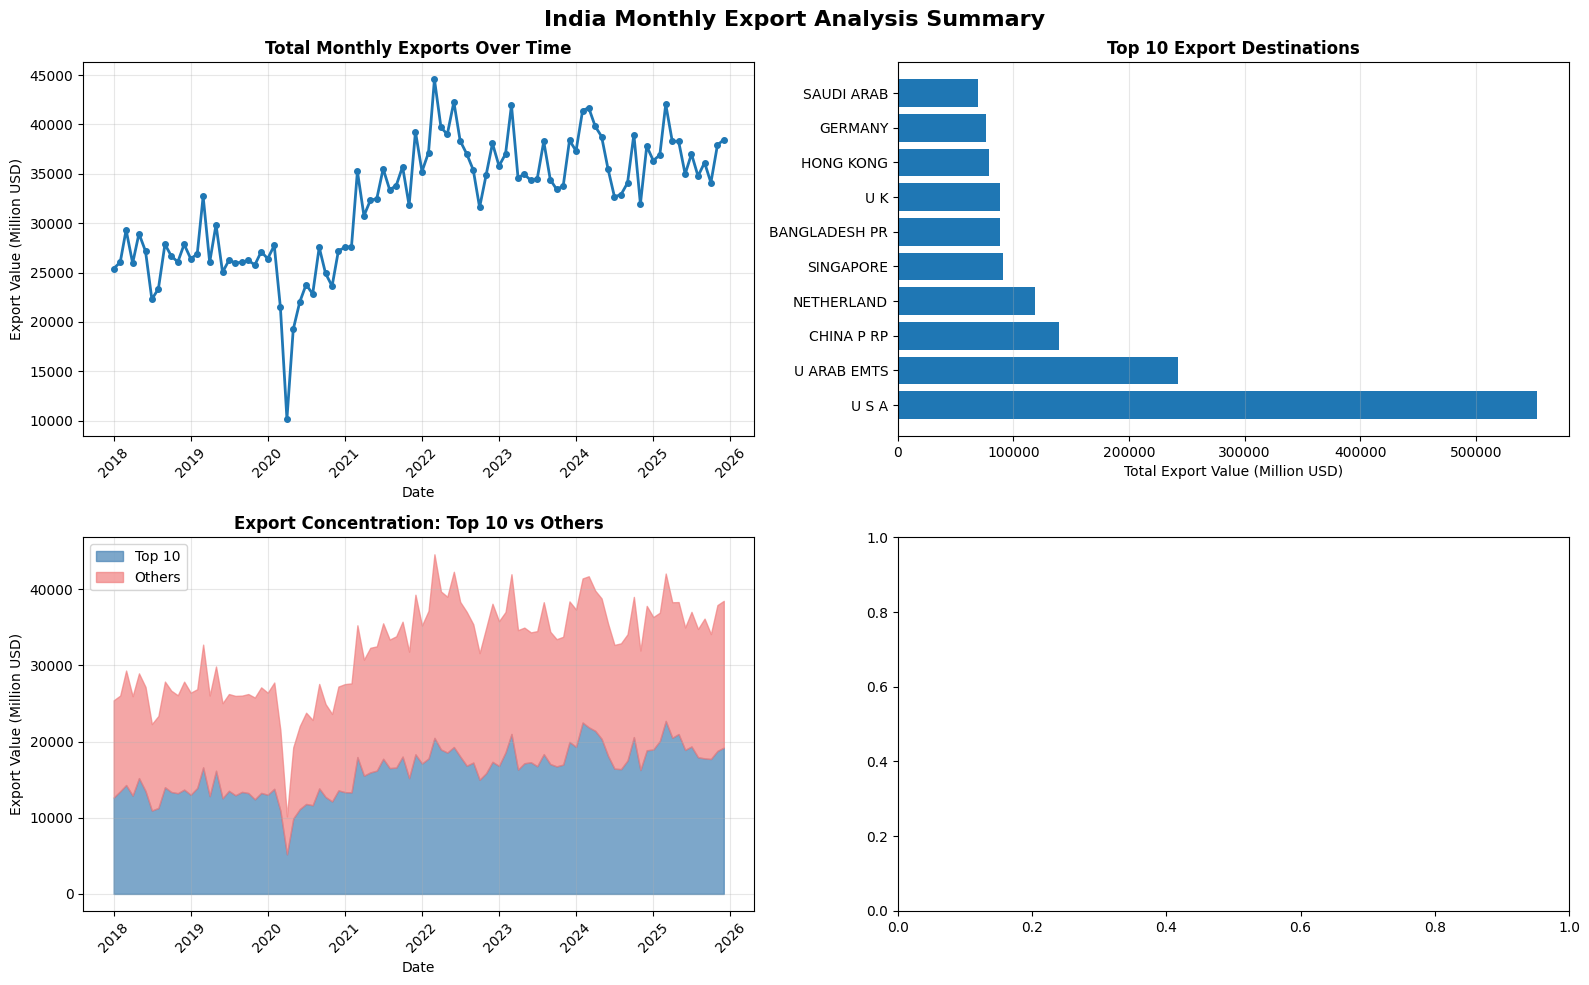

In [ ]:
# Creating the directory
os.makedirs('visualizations', exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('India Monthly Export Analysis Summary', fontsize=16, fontweight='bold')

# Plot 1: Monthly total exports
ax1 = axes[0, 0]
monthly_totals_sorted = monthly_totals.sort_index()
dates = pd.to_datetime(monthly_totals_sorted.index + '-01')
ax1.plot(dates, monthly_totals_sorted.values, marker='o', linewidth=2, markersize=4)
ax1.set_title('Total Monthly Exports Over Time', fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Export Value (Million USD)')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Top 10 countries
ax2 = axes[0, 1]
top10 = pivot.nlargest(10, 'TOTAL')['TOTAL']
ax2.barh(range(len(top10)), top10.values)
ax2.set_yticks(range(len(top10)))
ax2.set_yticklabels(top10.index)
ax2.set_title('Top 10 Export Destinations', fontweight='bold')
ax2.set_xlabel('Total Export Value (Million USD)')
ax2.grid(True, alpha=0.3, axis='x')

# Plot 3: Export concentration (top 10 vs rest)
ax3 = axes[1, 0]
top10_countries = pivot.nlargest(10, 'TOTAL').index
monthly_top10 = df_all[df_all['Country'].isin(top10_countries)].groupby('Year_Month')['Export_Value'].sum()
monthly_rest = df_all[~df_all['Country'].isin(top10_countries)].groupby('Year_Month')['Export_Value'].sum()

dates4 = pd.to_datetime(monthly_top10.sort_index().index + '-01')
ax3.fill_between(dates4, 0, monthly_top10.sort_index().values, alpha=0.7, label='Top 10', color='steelblue')  # ← ax4 → ax3
ax3.fill_between(dates4, monthly_top10.sort_index().values,                                                   # ← ax4 → ax3
                 monthly_top10.sort_index().values + monthly_rest.sort_index().values,
                 alpha=0.7, label='Others', color='lightcoral')
ax3.set_title('Export Concentration: Top 10 vs Others', fontweight='bold')
ax3.set_xlabel('Date')
ax3.set_ylabel('Export Value (Million USD)')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('visualizations/monthly_export_summary.png', dpi=300, bbox_inches='tight')
plt.show()

# ***VOLATILITY & RISK MATRIX***

In [ ]:
input_file = 'india_monthly_exports_analysis.xlsx'
df = pd.read_excel(input_file, sheet_name='Long Format')

##### loading MoM Growth again
if 'MoM Growth (%)' in df.columns:
    growth_col = 'MoM Growth (%)'
    print("data loaded")
else:
    print("not found")

##### Volatility matrix
print("CALCULATING VOLATILITY METRICS")

volatility_metrics = []

for country in df['Country'].unique():
    country_data = df[df['Country'] == country].copy().sort_values('Date')

    export_values = country_data['Export_Value'].values
    growth_values = country_data[growth_col].values

    # Non-zero exports
    non_zero_mask = (export_values > 0) & (~np.isnan(export_values))
    non_zero_exports = export_values[non_zero_mask]

    # Valid growth rates
    valid_growth = []
    for i in range(1, len(export_values)):
        if export_values[i] > 0 and export_values[i-1] > 0 and not np.isnan(growth_values[i]):
            valid_growth.append(growth_values[i])

    growth_rates = np.array(valid_growth) if len(valid_growth) > 0 else np.array([0])

    total_months = len(country_data)
    non_zero_months = len(non_zero_exports)
    valid_growth_months = len(growth_rates) if len(valid_growth) > 0 else 0


    ####### Calculate metrics
    if len(growth_rates) > 0 and valid_growth_months > 0:
        avg_growth = np.mean(growth_rates)
    else:
        avg_growth = 0

    if len(growth_rates) > 1:
        std_growth = np.std(growth_rates, ddof=1)
    else:
        std_growth = 0

    if abs(avg_growth) > 0.01 and std_growth > 0:
        cv = (std_growth / abs(avg_growth)) * 100
    else:
        cv = 0

    if len(growth_rates) > 0:
        growth_range = np.max(growth_rates) - np.min(growth_rates)
    else:
        growth_range = 0

    if len(growth_rates) > 0:
        negative_months = np.sum(growth_rates < 0)
        pct_negative = (negative_months / len(growth_rates)) * 100
    else:
        negative_months = 0
        pct_negative = 0

    if len(growth_rates) > 1:
        cumulative = np.cumprod(1 + growth_rates/100)
        running_max = np.maximum.accumulate(cumulative)
        drawdown = (cumulative - running_max) / running_max * 100
        max_drawdown = np.min(drawdown)
    else:
        max_drawdown = 0

    if len(non_zero_exports) > 0:
        avg_export = np.mean(non_zero_exports)
    else:
        avg_export = 0

    ######## Volatility Score
    std_score = min(std_growth / 50 * 100, 100) if std_growth > 0 else 0
    cv_score = min(abs(cv) / 200 * 100, 100) if cv > 0 else 0
    range_score = min(growth_range / 200 * 100, 100) if growth_range > 0 else 0
    negative_score = pct_negative
    drawdown_score = min(abs(max_drawdown) / 50 * 100, 100) if max_drawdown != 0 else 0

    volatility_score = (
        std_score * 0.30 +
        cv_score * 0.20 +
        range_score * 0.20 +
        negative_score * 0.15 +
        drawdown_score * 0.15
    )

    ######## Risk Classification (based on volatility score)
    if volatility_score < 20:
        risk_class, risk_level = "Very Low Risk", 1
    elif volatility_score < 40:
        risk_class, risk_level = "Low Risk", 2
    elif volatility_score < 60:
        risk_class, risk_level = "Medium Risk", 3
    elif volatility_score < 80:
        risk_class, risk_level = "High Risk", 4
    else:
        risk_class, risk_level = "Very High Risk", 5


    data_completeness = (non_zero_months / total_months) * 100 if total_months > 0 else 0
    #data completeness represent percentage of non zero export months

    volatility_metrics.append({
        'Country': country,
        'Total_Months': total_months,
        'Non_Zero_Months': non_zero_months,
        'Valid_Growth_Months': valid_growth_months,
        'Data_Completeness_%': round(data_completeness, 3),
        'Avg_MoM_Growth_%': round(avg_growth, 2),
        'StdDev_Growth': round(std_growth, 2),
        'Coeff_of_Variation': round(cv, 2),
        'Growth_Range_%': round(growth_range, 2),
        'Negative_Months': int(negative_months),
        'Pct_Negative_%': round(pct_negative, 2),
        'Max_Drawdown_%': round(max_drawdown, 2),
        'Avg_Export_Value': round(avg_export, 2),
        'Volatility_Score': round(volatility_score, 2),
        'Risk_Class': risk_class,
        'Risk_Level': risk_level
    })

volatility_df = pd.DataFrame(volatility_metrics).sort_values('Volatility_Score', ascending=False)


print("\nBy Data Completeness(non zero exports months):")
excellent = len(volatility_df[(volatility_df['Data_Completeness_%'] > 95) &
                              (volatility_df['Data_Completeness_%'] <= 100)])
good = len(volatility_df[(volatility_df['Data_Completeness_%'] > 80) &
                         (volatility_df['Data_Completeness_%'] <= 95)])
fair = len(volatility_df[(volatility_df['Data_Completeness_%'] > 50) &
                         (volatility_df['Data_Completeness_%'] <= 80)])
poor = len(volatility_df[(volatility_df['Data_Completeness_%'] > 20) &
                         (volatility_df['Data_Completeness_%'] <= 50)])
very_poor = len(volatility_df[(volatility_df['Data_Completeness_%'] > 0) &
                              (volatility_df['Data_Completeness_%'] <= 20)])
no_exports = len(volatility_df[volatility_df['Data_Completeness_%'] == 0])

print(f"  Excellent (95-100%):      {excellent:3d} countries")
print(f"  Good (80-95%):            {good:3d} countries")
print(f"  Fair (50-80%):            {fair:3d} countries")
print(f"  Poor (20-50%):            {poor:3d} countries")
print(f"  Very Poor (0-20%):        {very_poor:3d} countries")
print(f"  No Exports (0%):          {no_exports:3d} countries")


print("RISK DISTRIBUTION")

risk_categories = [
    ('Very High Risk', 5, 'red'),
    ('High Risk', 4, 'orange'),
    ('Medium Risk', 3, 'yellow'),
    ('Low Risk', 2, 'green'),
    ('Very Low Risk', 1, 'dark_green')
]

for risk_name, risk_level, color in risk_categories:
    countries = volatility_df[volatility_df['Risk_Class'] == risk_name]
    count = len(countries)
    pct = (count/len(volatility_df)*100) if len(volatility_df) > 0 else 0
    print(f"{risk_name.upper()}: {count} countries ({pct:.1f}%)")

####### Sort by volatility score descending
    if count > 0:
        countries_sorted = countries.sort_values('Volatility_Score', ascending=False)

         # Show top 5 for each category
        display_count = min(5, count)

        print(f"\nTop {display_count} countries by volatility score :")
        for idx, (_, row) in enumerate(countries_sorted.head(display_count).iterrows(), 1):
            print(f"{idx:2d}. {row['Country']:30s} | Score: {row['Volatility_Score']:6.2f} | "
                  f"Avg Export: ${row['Avg_Export_Value']:>10,.2f}M | "
                  f"Completeness: {row['Data_Completeness_%']:>6.1f}%")



        # If more than 10 country in each category
        if count > 10:
            print(f"\n & {count - 10} more countries in this category")

data loaded
CALCULATING VOLATILITY METRICS

By Data Completeness(non zero exports months):
  Excellent (95-100%):      199 countries
  Good (80-95%):              7 countries
  Fair (50-80%):              7 countries
  Poor (20-50%):              8 countries
  Very Poor (0-20%):         23 countries
  No Exports (0%):            7 countries
RISK DISTRIBUTION
VERY HIGH RISK: 170 countries (67.7%)

Top 5 countries by volatility score :
 1. SINT MAARTEN (DUTCH PART)      | Score:  95.92 | Avg Export: $      0.10M | Completeness:   14.6%
 2. ANTARTICA                      | Score:  93.57 | Avg Export: $      0.12M | Completeness:   18.8%
 3. LESOTHO                        | Score:  93.53 | Avg Export: $      1.80M | Completeness:  100.0%
 4. MARTINIQUE                     | Score:  93.39 | Avg Export: $      0.41M | Completeness:   99.0%
 5. PORTUGAL                       | Score:  93.37 | Avg Export: $     78.59M | Completeness:  100.0%

 & 160 more countries in this category
HIGH RISK: 5

In [ ]:
######## Excel
output_file = 'india_monthly_exports_analysis.xlsx'

book = load_workbook(input_file)
sheet_name = 'Volatility & Risk'

ws = book.create_sheet(sheet_name, 0)

# Headers
header_fill = PatternFill(start_color='C65911', end_color='C65911', fill_type='solid')
header_font = Font(bold=True, color='FFFFFF', size=11)

for col_idx, header in enumerate(volatility_df.columns, 1):
    cell = ws.cell(row=1, column=col_idx, value=header)
    cell.fill = header_fill
    cell.font = header_font
    cell.alignment = Alignment(horizontal='center', vertical='center')

# Data
for row_idx, (_, row) in enumerate(volatility_df.iterrows(), 2):
    for col_idx, value in enumerate(row, 1):
        ws.cell(row=row_idx, column=col_idx, value=value)

# Color-code Risk_Class
risk_col_idx = list(volatility_df.columns).index('Risk_Class') + 1
risk_colors = {
    'Very High Risk': 'FF0000',
    'High Risk': 'FFC000',
    'Medium Risk': 'FFFF00',
    'Low Risk': '92D050',
    'Very Low Risk': '00B050'
}

for row_idx in range(2, ws.max_row + 1):
    risk = ws.cell(row=row_idx, column=risk_col_idx).value
    if risk in risk_colors:
        ws.cell(row=row_idx, column=risk_col_idx).fill = PatternFill(
            start_color=risk_colors[risk], end_color=risk_colors[risk], fill_type='solid')
        ws.cell(row=row_idx, column=risk_col_idx).font = Font(bold=True)

# Auto-width
for col_idx in range(1, len(volatility_df.columns) + 1):
    ws.column_dimensions[get_column_letter(col_idx)].width = 18

ws.freeze_panes = 'B2'

book.save(output_file)
print(f" saved: {output_file}")
print(f" Sheet: '{sheet_name}'")

 saved: india_monthly_exports_analysis.xlsx
 Sheet: 'Volatility & Risk'


**VISUALIZATION 2.**

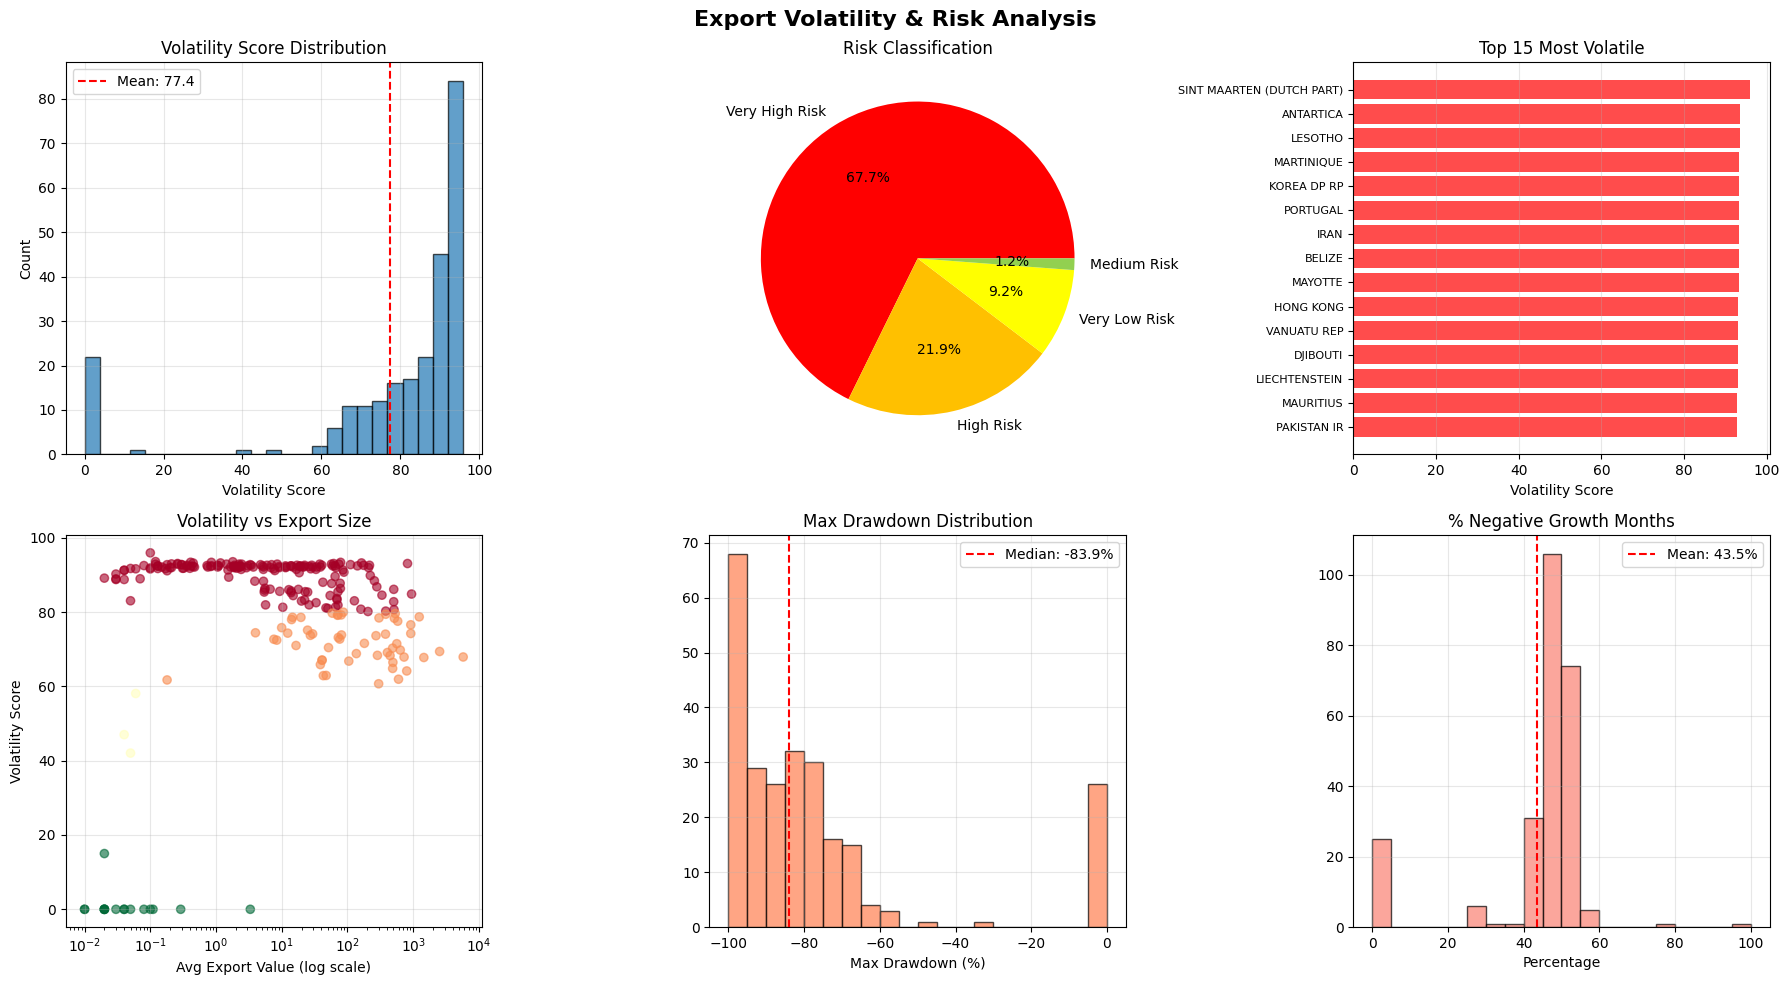

In [ ]:
# Risk visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Export Volatility & Risk Analysis', fontsize=16, fontweight='bold')

# Volatility distribution
axes[0, 0].hist(volatility_df['Volatility_Score'], bins=25, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(volatility_df['Volatility_Score'].mean(), color='red', linestyle='--',
                   label=f'Mean: {volatility_df["Volatility_Score"].mean():.1f}')
axes[0, 0].set_title('Volatility Score Distribution')
axes[0, 0].set_xlabel('Volatility Score')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Risk classification
risk_counts = volatility_df['Risk_Class'].value_counts()
axes[0, 1].pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%',
               colors=['#FF0000', '#FFC000', '#FFFF00', '#92D050', '#00B050'][:len(risk_counts)])
axes[0, 1].set_title('Risk Classification')

# Top 15 volatile
top15 = volatility_df.head(15).sort_values('Volatility_Score')
axes[0, 2].barh(range(len(top15)), top15['Volatility_Score'], color='red', alpha=0.7)
axes[0, 2].set_yticks(range(len(top15)))
axes[0, 2].set_yticklabels(top15['Country'], fontsize=8)
axes[0, 2].set_title('Top 15 Most Volatile')
axes[0, 2].set_xlabel('Volatility Score')
axes[0, 2].grid(True, alpha=0.3, axis='x')

# Volatility vs Size
axes[1, 0].scatter(volatility_df['Avg_Export_Value'], volatility_df['Volatility_Score'],
                   c=volatility_df['Risk_Level'], cmap='RdYlGn_r', alpha=0.6)
axes[1, 0].set_xscale('log')
axes[1, 0].set_title('Volatility vs Export Size')
axes[1, 0].set_xlabel('Avg Export Value (log scale)')
axes[1, 0].set_ylabel('Volatility Score')
axes[1, 0].grid(True, alpha=0.3)

# Max drawdown
axes[1, 1].hist(volatility_df['Max_Drawdown_%'], bins=20, edgecolor='black', alpha=0.7, color='coral')
axes[1, 1].axvline(volatility_df['Max_Drawdown_%'].median(), color='red', linestyle='--',
                   label=f'Median: {volatility_df["Max_Drawdown_%"].median():.1f}%')
axes[1, 1].set_title('Max Drawdown Distribution')
axes[1, 1].set_xlabel('Max Drawdown (%)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Negative months
axes[1, 2].hist(volatility_df['Pct_Negative_%'], bins=20, edgecolor='black', alpha=0.7, color='salmon')
axes[1, 2].axvline(volatility_df['Pct_Negative_%'].mean(), color='red', linestyle='--',
                   label=f'Mean: {volatility_df["Pct_Negative_%"].mean():.1f}%')
axes[1, 2].set_title('% Negative Growth Months')
axes[1, 2].set_xlabel('Percentage')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('visualizations/volatility_risk_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

***MERGING YEARLY INDICATORS WITH MONTHLY EXPORT DATA***

In [ ]:
# GDP: quarterly -> expand to monthly
# Q1=Jan-Mar  Q2=Apr-Jun  Q3=Jul-Sep  Q4=Oct-Dec  (calendar year)
gdp_raw = pd.read_excel('/content/gdp_growth.xlsx')
gdp_raw.columns = gdp_raw.columns.str.strip()
gdp_raw.rename(columns={'gdp growth': 'gdp_growth'}, inplace=True)

quarter_month_map = {'Q1':[1,2,3], 'Q2':[4,5,6], 'Q3':[7,8,9], 'Q4':[10,11,12]}
gdp_monthly_rows = []
for _, row in gdp_raw.iterrows():
    for month in quarter_month_map[row['Quarter']]:
        gdp_monthly_rows.append({
            'Year': int(row['Year']),
            'Month': month,
            'gdp_growth': float(row['gdp_growth'])
        })
gdp_monthly = pd.DataFrame(gdp_monthly_rows)
print(f"\nGDP expanded: {len(gdp_monthly)} monthly rows  "
      f"({gdp_monthly['gdp_growth'].nunique()} unique values, was 8)")

# Inflation: monthly directly
inf_raw = pd.read_excel('/content/Inflation.xlsx')
inf_raw.columns = inf_raw.columns.str.strip()
inf_raw.rename(columns={'Inflation': 'Inflation_rate'}, inplace=True)
inf_raw['Inflation_rate'] = pd.to_numeric(inf_raw['Inflation_rate'], errors='coerce')
inf_raw['Inflation_rate'] = inf_raw['Inflation_rate'].ffill()
month_str_map = {'Jan':1,'Feb':2,'Mar':3,'Apr':4,'May':5,'Jun':6,
                 'Jul':7,'Aug':8,'Sep':9,'Oct':10,'Nov':11,'Dec':12}
inf_raw['Month'] = inf_raw['Month'].map(month_str_map)
inf_raw = inf_raw[['Year','Month','Inflation_rate']]
print(f"Inflation: {len(inf_raw)} monthly rows")

# REER: monthly directly
reer_raw = pd.read_excel('/content/REER.xlsx')
reer_raw.columns = reer_raw.columns.str.strip()
reer_raw['date']  = pd.to_datetime(reer_raw['date'])
reer_raw['Year']  = reer_raw['date'].dt.year
reer_raw['Month'] = reer_raw['date'].dt.month
reer_raw = reer_raw[['Year','Month','REER']]
print(f"REER: {len(reer_raw)} monthly rows")

# Load monthly export data
export_file    = 'india_monthly_exports_analysis.xlsx'
monthly_exports = pd.read_excel(export_file, sheet_name='Long Format')
if 'Year' not in monthly_exports.columns:
    monthly_exports['Year'] = pd.to_datetime(monthly_exports['Date']).dt.year
if 'Month' not in monthly_exports.columns:
    monthly_exports['Month'] = pd.to_datetime(monthly_exports['Date']).dt.month

# Merge all
merged_data = monthly_exports.merge(gdp_monthly, on=['Year','Month'], how='left')
merged_data = merged_data.merge(inf_raw,         on=['Year','Month'], how='left')
merged_data = merged_data.merge(reer_raw,        on=['Year','Month'], how='left')

print(f"\nMerged Data Shape: {merged_data.shape}")
print(f"Columns: {list(merged_data.columns)}")
missing_indicators = merged_data[['gdp_growth','Inflation_rate','REER']].isnull().sum()
print(f"\nMissing values after merge:\n{missing_indicators}")

year_summary = merged_data.groupby('Year').agg({
    'Export_Value':    ['count','sum','mean'],
    'gdp_growth':      'first',
    'Inflation_rate':  'first',
    'REER':            'mean'
}).round(2)
year_summary.columns = ['Month_Count','Total_Exports','Avg_Export',
                         'GDP_Growth_%','Inflation_%','Avg_REER']
print(year_summary)

output_file = 'india_monthly_exports_with_indicators.xlsx'
with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    merged_data.to_excel(writer, sheet_name='Complete Data', index=False)
    monthly_totals = merged_data.groupby('Date').agg(
        Export_Value  =('Export_Value',   'sum'),
        gdp_growth    =('gdp_growth',     'first'),
        Inflation_rate=('Inflation_rate', 'first'),
        REER          =('REER',           'first')
    ).reset_index()
    monthly_totals.to_excel(writer, sheet_name='Monthly Totals', index=False)
print(f"Saved: {output_file}")


GDP expanded: 96 monthly rows  (27 unique values, was 8)
Inflation: 96 monthly rows
REER: 96 monthly rows

Merged Data Shape: (24096, 13)
Columns: ['Country', 'Export_Value', 'Year', 'Month', 'Month_Name', 'Date', 'Year_Month', 'Monthly_Total', 'Export_Share_%', 'MoM Growth (%)', 'gdp_growth', 'Inflation_rate', 'REER']

Missing values after merge:
gdp_growth        0
Inflation_rate    0
REER              0
dtype: int64
      Month_Count  Total_Exports  Avg_Export  GDP_Growth_%  Inflation_%  \
Year                                                                      
2018         3012      316928.45      105.22           7.7         5.07   
2019         3012      324267.38      107.66           5.2         1.97   
2020         3012      277023.29       91.97           3.1         7.59   
2021         3012      395471.82      131.30          20.1         4.06   
2022         3012      453259.89      150.48           4.0         6.01   
2023         3012      431420.84      143.23       

# ***CORRELATION ANALYSIS: EXPORTS vs MACRO INDICATORS***

**with annual export**

In [ ]:
input_file = 'india_monthly_exports_with_indicators.xlsx'
df = pd.read_excel(input_file, sheet_name='Complete Data')
df.columns = df.columns.str.strip()
print(f"\nLoaded merged data: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")

if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
if 'Year' not in df.columns:
    df['Year'] = df['Date'].dt.year

yearly = df.groupby('Year').agg(
    Avg_Monthly_Export   = ('Export_Value',   'mean'),
    Total_Annual_Export  = ('Export_Value',   'sum'),
    Median_Monthly_Export= ('Export_Value',   'median'),
    StdDev_Export        = ('Export_Value',   'std'),
    Num_Months           = ('Export_Value',   'count'),
    GDP_Growth           = ('gdp_growth',     'first'),
    Inflation_Rate       = ('Inflation_rate', 'first'),
    Avg_REER             = ('REER',           'mean'),
).reset_index().round(2)
yearly['CV_Export_%'] = (yearly['StdDev_Export']/yearly['Avg_Monthly_Export']*100).round(2)

print("\nYearly Summary Table:")
print(yearly[['Year','Avg_Monthly_Export','Total_Annual_Export',
              'GDP_Growth','Inflation_Rate','Avg_REER']].to_string(index=False))

reg_pairs = [
    ('GDP_Growth',  'Avg_Monthly_Export',  'Avg Exports ~ GDP Growth'),
    ('Inflation_Rate','Avg_Monthly_Export','Avg Exports ~ Inflation'),
    ('Avg_REER',    'Avg_Monthly_Export',  'Avg Exports ~ REER'),
    ('GDP_Growth',  'Total_Annual_Export', 'Total Exports ~ GDP Growth'),
    ('Inflation_Rate','Total_Annual_Export','Total Exports ~ Inflation'),
    ('Avg_REER',    'Total_Annual_Export', 'Total Exports ~ REER'),
]

reg_results = []
for x_col, y_col, label in reg_pairs:
    slope, intercept, r, p, se = stats.linregress(yearly[x_col], yearly[y_col])
    reg_results.append({
        'Model': label, 'X': x_col, 'Y': y_col,
        'Slope': round(slope,2), 'Intercept': round(intercept,2),
        'R_squared': round(r**2,4), 'P_Value': round(p,4), 'Std_Error': round(se,4)
    })
    print(f"\n  {label}")
    print(f"  Slope = {slope:+.2f}  R² = {r**2:.4f}  p-value = {p:.4f}")

reg_df = pd.DataFrame(reg_results)

corr_cols = ['Avg_Monthly_Export','Total_Annual_Export','GDP_Growth',
             'Inflation_Rate','Avg_REER','CV_Export_%','StdDev_Export']
corr_matrix = yearly[corr_cols].corr().round(3)
print("\n", corr_matrix.to_string())

r_exp_gdp, _ = stats.pearsonr(yearly['Avg_Monthly_Export'], yearly['GDP_Growth'])
r_exp_inf, _ = stats.pearsonr(yearly['Avg_Monthly_Export'], yearly['Inflation_Rate'])
r_exp_rer, _ = stats.pearsonr(yearly['Avg_Monthly_Export'], yearly['Avg_REER'])
r_gdp_inf, _ = stats.pearsonr(yearly['GDP_Growth'], yearly['Inflation_Rate'])

print(f"""
Exports -- GDP Growth  r = {r_exp_gdp:+.3f}
Exports -- Inflation   r = {r_exp_inf:+.3f}
Exports -- REER        r = {r_exp_rer:+.3f}
GDP Growth -- Inflation r = {r_gdp_inf:+.3f}""")


Loaded merged data: 24,096 rows, 13 columns
Columns: ['Country', 'Export_Value', 'Year', 'Month', 'Month_Name', 'Date', 'Year_Month', 'Monthly_Total', 'Export_Share_%', 'MoM Growth (%)', 'gdp_growth', 'Inflation_rate', 'REER']

Yearly Summary Table:
 Year  Avg_Monthly_Export  Total_Annual_Export  GDP_Growth  Inflation_Rate  Avg_REER
 2018              105.22            316928.45         7.7            5.07     97.39
 2019              107.66            324267.38         5.2            1.97     99.37
 2020               91.97            277023.29         3.1            7.59    100.00
 2021              131.30            395471.82        20.1            4.06     99.91
 2022              150.48            453259.89         4.0            6.01    100.91
 2023              143.23            431420.84         6.1            6.52     99.42
 2024              147.02            442829.36         6.7            5.10    102.12
 2025              147.83            445256.71         7.6           

**VISUALIZATION 3.**

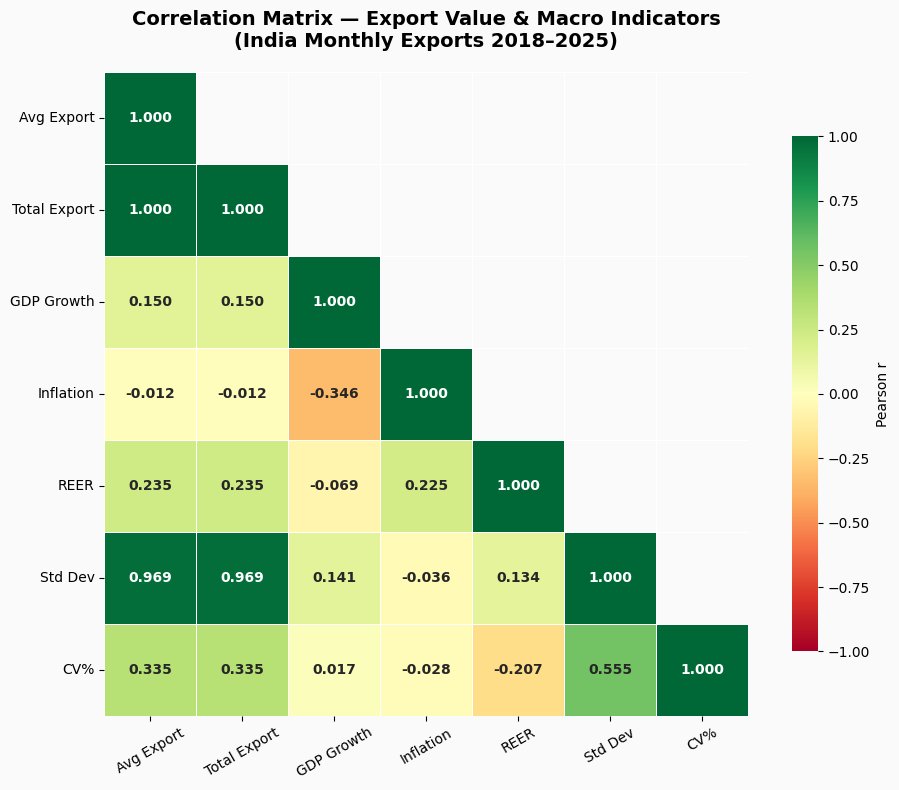

In [ ]:
def fmt_m(x, _):
    """Format y-axis as $XXk M"""
    return f'${x/1000:.0f}k'

COLORS = {
    'actual'  : '#2C3E50',
    'arima'   : '#2980B9',
    'lstm'    : '#27AE60',
    'hybrid'  : '#E67E22',
    'ci'      : '#AED6F1',
    'ci2'     : '#A9DFBF',
    'ci3'     : '#FAD7A0',
    'grid'    : '#ECF0F1',
    'covid'   : '#E74C3C',
}

corr_cols = ['Avg_Monthly_Export', 'Total_Annual_Export',
             'GDP_Growth', 'Inflation_Rate', 'Avg_REER',
             'StdDev_Export']

# Compute CV if not present
if 'CV_Export_%' in yearly.columns:
    corr_cols.append('CV_Export_%')

corr_matrix = yearly[corr_cols].corr().round(3)

# Rename for display
display_labels = {
    'Avg_Monthly_Export' : 'Avg Export',
    'Total_Annual_Export': 'Total Export',
    'GDP_Growth'         : 'GDP Growth',
    'Inflation_Rate'     : 'Inflation',
    'Avg_REER'           : 'REER',
    'StdDev_Export'      : 'Std Dev',
    'CV_Export_%'        : 'CV%',
}
corr_display = corr_matrix.rename(
    index=display_labels, columns=display_labels)

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

mask = np.triu(np.ones_like(corr_display, dtype=bool), k=1)  # hide upper triangle

sns.heatmap(
    corr_display,
    ax=ax,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    vmin=-1, vmax=1,
    center=0,
    linewidths=0.5,
    linecolor='white',
    square=True,
    mask=mask,
    annot_kws={'size': 10, 'weight': 'bold'},
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'},
)

ax.set_title('Correlation Matrix — Export Value & Macro Indicators\n'
             '(India Monthly Exports 2018–2025)',
             fontsize=14, fontweight='bold', pad=18)
ax.tick_params(axis='x', rotation=30, labelsize=10)
ax.tick_params(axis='y', rotation=0,  labelsize=10)

# Highlight the export row/column
for spine in ax.spines.values():
    spine.set_edgecolor('#BDC3C7')

plt.tight_layout()
plt.savefig('visualizations/correlation_matrix.png', dpi=300,
            bbox_inches='tight', facecolor='#FAFAFA')
plt.show()


***with monthly export***

In [ ]:
input_file = 'india_monthly_exports_with_indicators.xlsx'
df = pd.read_excel(input_file, sheet_name='Complete Data')
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'])

# Build monthly
monthly = (df
    .groupby('Date')
    .agg(
        Total_Export   = ('Export_Value',   'sum'),
        GDP_Growth     = ('gdp_growth',     'first'),
        Inflation_Rate = ('Inflation_rate', 'first'),
        REER           = ('REER',           'first')
    )
    .reset_index()
    .sort_values('Date')
)

print(f"Monthly correlation dataset : {len(monthly)} observations")
print(f"Period : {monthly['Date'].min().strftime('%b %Y')} "
      f"→ {monthly['Date'].max().strftime('%b %Y')}")
print(f"\nDescriptive Statistics:")
print(monthly[['Total_Export','GDP_Growth','Inflation_Rate','REER']].describe().round(2))

#  Pearson correlation &ignificance
print(f"  PEARSON CORRELATION  —  MONTHLY  (n = {len(monthly)})")
print(f"  {'Pair':<40} {'r':>8} {'p-value':>10} {'Sig':>6}")


pairs = [
    ('Total_Export',   'GDP_Growth',     'Export ~ GDP Growth'),
    ('Total_Export',   'Inflation_Rate', 'Export ~ Inflation'),
    ('Total_Export',   'REER',           'Export ~ REER'),
    ('GDP_Growth',     'Inflation_Rate', 'GDP Growth ~ Inflation'),
    ('GDP_Growth',     'REER',           'GDP Growth ~ REER'),
    ('Inflation_Rate', 'REER',           'Inflation ~ REER'),
]

corr_results = []
for x_col, y_col, label in pairs:
    r, p = stats.pearsonr(monthly[x_col].values, monthly[y_col].values)
    sig  = ('***' if p < 0.001 else '**' if p < 0.01
            else '*' if p < 0.05 else 'n.s.')
    corr_results.append({'Pair': label, 'r': round(r,4),
                         'p_value': round(p,4), 'Sig': sig})
    print(f"  {label:<40} {r:>8.4f} {p:>10.4f} {sig:>6}")

print(f"\n  Significance: *** p<0.001  ** p<0.01  * p<0.05  n.s. not significant")
print(f"  Critical |r| for significance at α=0.05 (n={len(monthly)}, two-tailed): ±0.201")

# Full correlation matrix
rename_map = {
    'Total_Export':   'Total Export',
    'GDP_Growth':     'GDP Growth',
    'Inflation_Rate': 'Inflation',
    'REER':           'REER'
}
corr_matrix = (monthly[list(rename_map.keys())]
               .rename(columns=rename_map)
               .corr()
               .round(4))

print(f"\nFull Correlation Matrix (Monthly, n={len(monthly)}):")
print(corr_matrix.to_string())


Monthly correlation dataset : 96 observations
Period : Jan 2018 → Dec 2025

Descriptive Statistics:
       Total_Export  GDP_Growth  Inflation_Rate    REER
count         96.00       96.00           96.00   96.00
mean       32150.60        5.75            4.85   99.51
std         6228.88        6.35            1.70    2.43
min        10173.28      -23.90            0.25   92.89
25%        26818.12        5.15            3.68   97.82
50%        33589.71        6.65            4.97   99.82
75%        37017.59        7.62            6.10  101.29
max        44573.67       20.10            7.79  104.72
  PEARSON CORRELATION  —  MONTHLY  (n = 96)
  Pair                                            r    p-value    Sig
  Export ~ GDP Growth                        0.5170     0.0000    ***
  Export ~ Inflation                         0.0212     0.8373   n.s.
  Export ~ REER                              0.1074     0.2976   n.s.
  GDP Growth ~ Inflation                    -0.1500     0.1446   n.s.
  

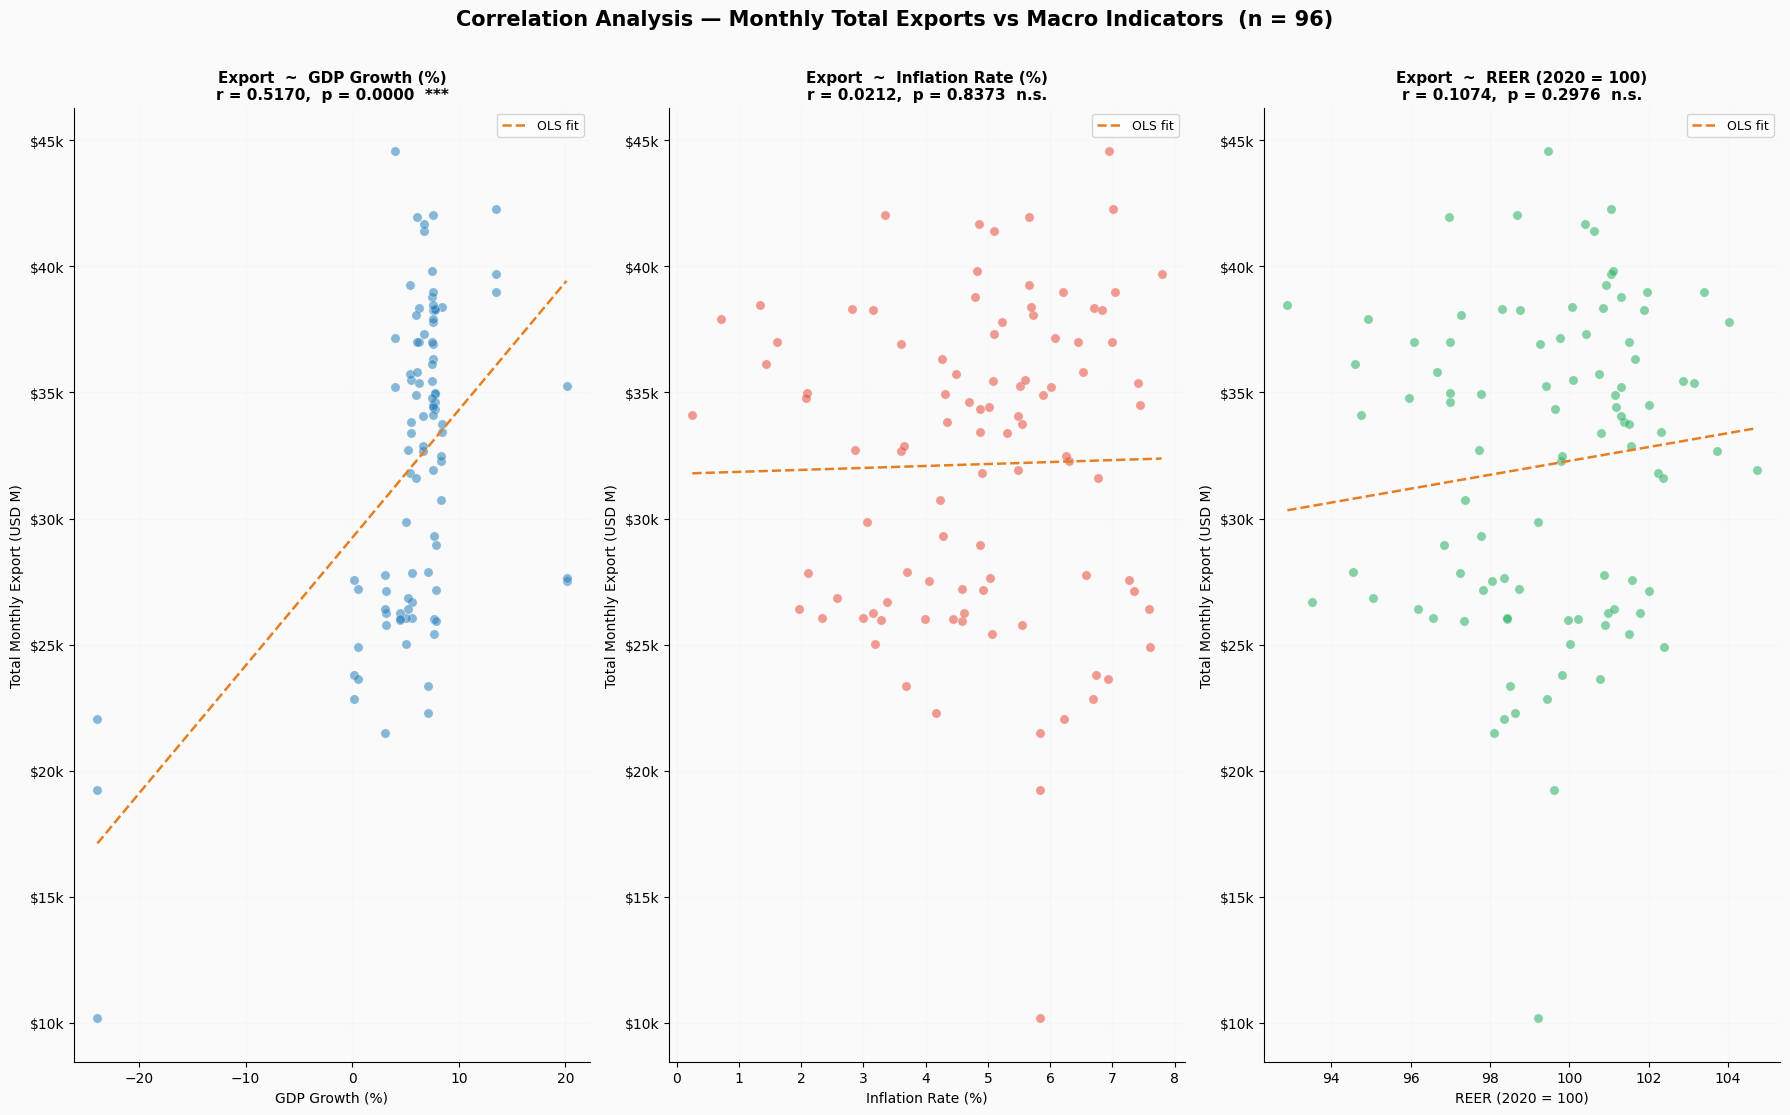

In [ ]:
COLORS = {
    'gdp':   '#2980B9',
    'inf':   '#E74C3C',
    'reer':  '#27AE60',
    'export':'#2C3E50',
    'fit':   '#E67E22',
    'grid':  '#ECF0F1',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 11))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle(
    f'Correlation Analysis — Monthly Total Exports vs Macro Indicators  (n = {len(monthly)})',
    fontsize=15, fontweight='bold', y=1.01
)

dates = monthly['Date']
scatter_cfg = [
    ('GDP_Growth',     'GDP Growth (%)',      COLORS['gdp']),
    ('Inflation_Rate', 'Inflation Rate (%)',  COLORS['inf']),
    ('REER',           'REER (2020 = 100)',   COLORS['reer']),
]

#  Scatter plots
for i, (x_col, x_label, color) in enumerate(scatter_cfg):
    ax  = axes[i]
    ax.set_facecolor('#FAFAFA')

    x = monthly[x_col].values
    y = monthly['Total_Export'].values

    ax.scatter(x, y, alpha=0.55, color=color, s=45,
               edgecolors='white', linewidth=0.4, zorder=3)

    # OLS fit line
    slope, intercept, r, p, _ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, slope * x_line + intercept,
            color=COLORS['fit'], linewidth=1.8, linestyle='--',
            label='OLS fit', zorder=4)

    sig = ('***' if p < 0.001 else '**' if p < 0.01
           else '*' if p < 0.05 else 'n.s.')
    ax.set_title(f'Export  ~  {x_label}\nr = {r:.4f},  p = {p:.4f}  {sig}',
                 fontweight='bold', fontsize=11)
    ax.set_xlabel(x_label, fontsize=10)
    ax.set_ylabel('Total Monthly Export (USD M)', fontsize=10)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda v, _: f'${v/1000:.0f}k'))
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, color=COLORS['grid'])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('visualizations/correlation_monthly.png',
            dpi=300, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()


In [ ]:
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf as sm_acf
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ***FORECASTING : India Monthly Export Forecasting (2018–2025)***


# **1. ARIMAX** (Arima with exogeneous variable)

In [ ]:
input_file = 'india_monthly_exports_with_indicators.xlsx'
df = pd.read_excel(input_file, sheet_name='Complete Data')
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'])

monthly = (df.groupby('Date')
             .agg(Export_Value   = ('Export_Value',   'sum'),
                  GDP_Growth      = ('gdp_growth',      'first'),
                  Inflation_Rate = ('Inflation_rate',  'first'),
                  REER           = ('REER',            'first'))
             .reset_index()
             .sort_values('Date'))
monthly.set_index('Date', inplace=True)
monthly.index = pd.DatetimeIndex(monthly.index).to_period('M')

print(f"\nMonthly series loaded: {len(monthly)} observations")
print(f"Range : {monthly.index[0]}  →  {monthly.index[-1]}")

def adf_summary(series, name, alpha=0.05):
    result = adfuller(series.dropna(), autolag='AIC')
    adf_stat, p_val, lags_used, nobs, crit = (result[0],result[1],
                                               result[2],result[3],result[4])
    stationary = p_val < alpha
    print(f"\n  Variable  : {name}")
    print(f"  ADF Stat  : {adf_stat:.4f}")
    print(f"  p-value   : {p_val:.4f}")
    print(f"  Lags used : {lags_used}")
    print(f"  Crit vals : 1%={crit['1%']:.3f}  5%={crit['5%']:.3f}  10%={crit['10%']:.3f}")
    print(f"  Decision  : {'✓ STATIONARY' if stationary else '✗ NON-STATIONARY'} (α={alpha})")
    return stationary, p_val

stat_exp, _ = adf_summary(monthly['Export_Value'],   'Export_Value   (level)')
stat_gdp, _ = adf_summary(monthly['GDP_Growth'],     'GDP_Growth     (level)')
stat_inf, _ = adf_summary(monthly['Inflation_Rate'], 'Inflation_Rate (level)')
stat_rer, _ = adf_summary(monthly['REER'],           'REER           (level)')

d_order     = 0
export_work = monthly['Export_Value'].copy()
if not stat_exp:
    export_d1   = monthly['Export_Value'].diff().dropna()
    stat_d1, _  = adf_summary(export_d1, 'Export_Value (1st diff)')
    d_order     = 1
    export_work = export_d1
    if not stat_d1:
        export_d2   = export_d1.diff().dropna()
        adf_summary(export_d2, 'Export_Value (2nd diff)')
        d_order     = 2
        export_work = export_d2

gdp_work = monthly['GDP_Growth'].copy()
inf_work = monthly['Inflation_Rate'].copy()
rer_work = monthly['REER'].copy()
if d_order == 1:
    gdp_work = gdp_work.diff()
    inf_work = inf_work.diff()
    rer_work = rer_work.diff()
    print("exogenous variables 1st diff")
if d_order == 2:
    gdp_work = gdp_work.diff()
    inf_work = inf_work.diff()
    rer_work = rer_work.diff()
    print("exogenous variables 2nd diff")

# Step 1: Use level data for endogenous variable
endog_fit = monthly['Export_Value'].dropna()

# Step 2: Use LEVEL (not differenced) exogenous variables
# ARIMA(p,d,q) handles the differencing of endog internally.
# Exogenous regressors enter in LEVELS.
exog_fit = monthly[['GDP_Growth', 'Inflation_Rate', 'REER']].loc[endog_fit.index]
exog_fit = exog_fit.ffill().dropna()

# Align
valid_idx = endog_fit.index.intersection(exog_fit.index)
endog_fit = endog_fit.loc[valid_idx]
exog_fit = exog_fit.loc[valid_idx]

# Step 3: Grid search with d=1 (from ADF test)
d_order = 1   # Export value became stationary after 1st diff

print("\n final working series length after differencing: "
      f"{len(endog_fit)},{len(exog_fit)}")
print(f" NaN check — endog: {endog_fit.isnull().sum()}  "
      f"exog: {exog_fit.isnull().sum().sum()}")

print(" ARIMA GRID SEARCH — Best (p, d, q) by AIC")
p_range = range(0, 4)
q_range = range(0, 4)
results_list = []
print(f"\n  Searching p ∈ {list(p_range)}, d={d_order}, q ∈ {list(q_range)} …\n")

for p, q in itertools.product(p_range, q_range):
    try:
        model = ARIMA(
            endog = endog_fit,
            exog  = exog_fit,
            order = (p, d_order, q)
        )
        fit = model.fit(method_kwargs={"warn_convergence": False})
        results_list.append({
            'p':p,'d':d_order,'q':q,
            'AIC':round(fit.aic,2),'BIC':round(fit.bic,2),
            'HQIC':round(fit.hqic,2),'LL':round(fit.llf,2),
            'Converged':True
        })
        print(f"  ARIMA({p},{d_order},{q})  AIC={fit.aic:.2f}  BIC={fit.bic:.2f}")
    except Exception as e:
        results_list.append({'p':p,'d':d_order,'q':q,'AIC':np.nan,
                             'BIC':np.nan,'HQIC':np.nan,'LL':np.nan,'Converged':False})

grid_df  = pd.DataFrame(results_list).dropna(subset=['AIC']).sort_values('AIC')
print(f"\n  Top 10 models by AIC:")
print(grid_df.head(10).to_string(index=False))

best    = grid_df.iloc[0]
best_p, best_d, best_q = int(best.p), int(best.d), int(best.q)
print(f"\n  BEST MODEL: ARIMA({best_p},{best_d},{best_q})")
print(f"  AIC = {best.AIC}   BIC = {best.BIC}   HQIC = {best.HQIC}")

print(f" FITTING BEST MODEL — ARIMA({best_p},{best_d},{best_q})")
best_model = ARIMA(
    endog = endog_fit,
    exog  = exog_fit,
    order = (best_p, best_d, best_q)
)
best_fit = best_model.fit(method_kwargs={"warn_convergence": False})
print(best_fit.summary())

print("RESIDUAL DIAGNOSTICS")
residuals = best_fit.resid
lb = acorr_ljungbox(residuals.dropna(), lags=[5, 10, 15, 20], return_df=True)
print("\nLjung-Box (H0: residuals are white noise):")
print(lb.to_string())

jb_stat, jb_p = stats.jarque_bera(residuals.dropna()) # Corrected: only unpack 2 values
sk_val = stats.skew(residuals.dropna())
ku_val = stats.kurtosis(residuals.dropna())


# In-sample accuracy
fitted_vals = best_fit.fittedvalues
common = monthly['Export_Value'].dropna().index.intersection(fitted_vals.dropna().index)
y_true_is = monthly['Export_Value'].loc[common].values
y_pred_is = fitted_vals.loc[common].values
rmse_is = np.sqrt(mean_squared_error(y_true_is, y_pred_is))
mae_is  = mean_absolute_error(y_true_is, y_pred_is)
mape_is = np.mean(np.abs((y_true_is - y_pred_is) / np.where(y_true_is == 0, np.nan, y_true_is))) * 100
r2_is   = 1 - np.sum((y_true_is - y_pred_is)**2) / np.sum((y_true_is - y_true_is.mean())**2)
print(f"\nIn-sample: RMSE={rmse_is:.2f}  MAE={mae_is:.2f}  MAPE={mape_is:.2f}%  R²={r2_is:.4f}")

# OOS validation
# Step 4: OOS validation
N_TEST = 12
oos_model = ARIMA(
    endog=endog_fit.iloc[:-N_TEST],
    exog=exog_fit.iloc[:-N_TEST],
    order=(best_p, d_order, best_q)
).fit(
    method_kwargs={"warn_convergence": False})
oos_fc = oos_model.get_forecast(
    steps=N_TEST,
    exog=exog_fit.iloc[-N_TEST:]   # Use LEVEL exog for forecast too
)

oos_pred = oos_fc.predicted_mean
oos_ci   = oos_fc.conf_int(alpha=0.05)
oos_mae  = mean_absolute_error(endog_fit.iloc[-N_TEST:].values, oos_pred)
oos_mape = np.mean(np.abs((endog_fit.iloc[-N_TEST:].values - oos_pred) / np.where(endog_fit.iloc[-N_TEST:].values == 0, np.nan, endog_fit.iloc[-N_TEST:].values))) * 100
oos_rmse = np.sqrt(mean_squared_error(endog_fit.iloc[-N_TEST:].values, oos_pred))
print(f"OOS ({N_TEST}m): RMSE={oos_rmse:.2f}  MAPE={oos_mape:.2f}%\n")


# Future 12-month forecast
# Step 5: Future forecast
# Use last known values of exog (or projected values)
last_gdp  = monthly['GDP_Growth'].iloc[-1]
last_inf  = monthly['Inflation_Rate'].iloc[-1]
last_reer = monthly['REER'].iloc[-1]
fut_exog = pd.DataFrame({
    'GDP_Growth':    [last_gdp]  * 12,
    'Inflation_Rate': [last_inf]  * 12,
    'REER':           [last_reer] * 12
})
future_fc = best_fit.get_forecast(steps=12, exog=fut_exog)
future_mean = future_fc.predicted_mean
future_ci   = future_fc.conf_int(alpha=0.05)
future_periods = pd.period_range(start=monthly.index[-1] + 1, periods=12, freq='M')
future_mean.index = future_ci.index = future_periods

print(f"\n12-Month ARIMA Forecast (USD Million):")
print(f"  {'Month':<12} {'Forecast':>12} {'Lower 95%':>12} {'Upper 95%':>12}")
for p in future_periods:
    lo, hi = future_ci.loc[p].iloc[0], future_ci.loc[p].iloc[1]
    print(f"  {str(p):<12} {future_mean[p]:>12.2f} {lo:>12.2f} {hi:>12.2f}")


print(f"""
ACCURACY METRICS
    In-sample   RMSE  = {rmse_is:>10.2f} USD M
                MAE   = {mae_is:>10.2f} USD M
                MAPE  = {mape_is:>10.2f} %
                R²    = {r2_is:>10.4f}
    Out-of-sample
                RMSE  = {oos_rmse:>10.2f} USD M
                MAE   = {oos_mae:>10.2f} USD M
                MAPE  = {oos_mape:>10.2f} %
      """)


Monthly series loaded: 96 observations
Range : 2018-01  →  2025-12

  Variable  : Export_Value   (level)
  ADF Stat  : -2.0152
  p-value   : 0.2800
  Lags used : 1
  Crit vals : 1%=-3.502  5%=-2.893  10%=-2.583
  Decision  : ✗ NON-STATIONARY (α=0.05)

  Variable  : GDP_Growth     (level)
  ADF Stat  : -1.6447
  p-value   : 0.4598
  Lags used : 12
  Crit vals : 1%=-3.512  5%=-2.897  10%=-2.586
  Decision  : ✗ NON-STATIONARY (α=0.05)

  Variable  : Inflation_Rate (level)
  ADF Stat  : -1.5773
  p-value   : 0.4950
  Lags used : 12
  Crit vals : 1%=-3.512  5%=-2.897  10%=-2.586
  Decision  : ✗ NON-STATIONARY (α=0.05)

  Variable  : REER           (level)
  ADF Stat  : -2.5915
  p-value   : 0.0948
  Lags used : 1
  Crit vals : 1%=-3.502  5%=-2.893  10%=-2.583
  Decision  : ✗ NON-STATIONARY (α=0.05)

  Variable  : Export_Value (1st diff)
  ADF Stat  : -9.6290
  p-value   : 0.0000
  Lags used : 1
  Crit vals : 1%=-3.503  5%=-2.893  10%=-2.584
  Decision  : ✓ STATIONARY (α=0.05)
exogenous var

VISUALIZATION 4.

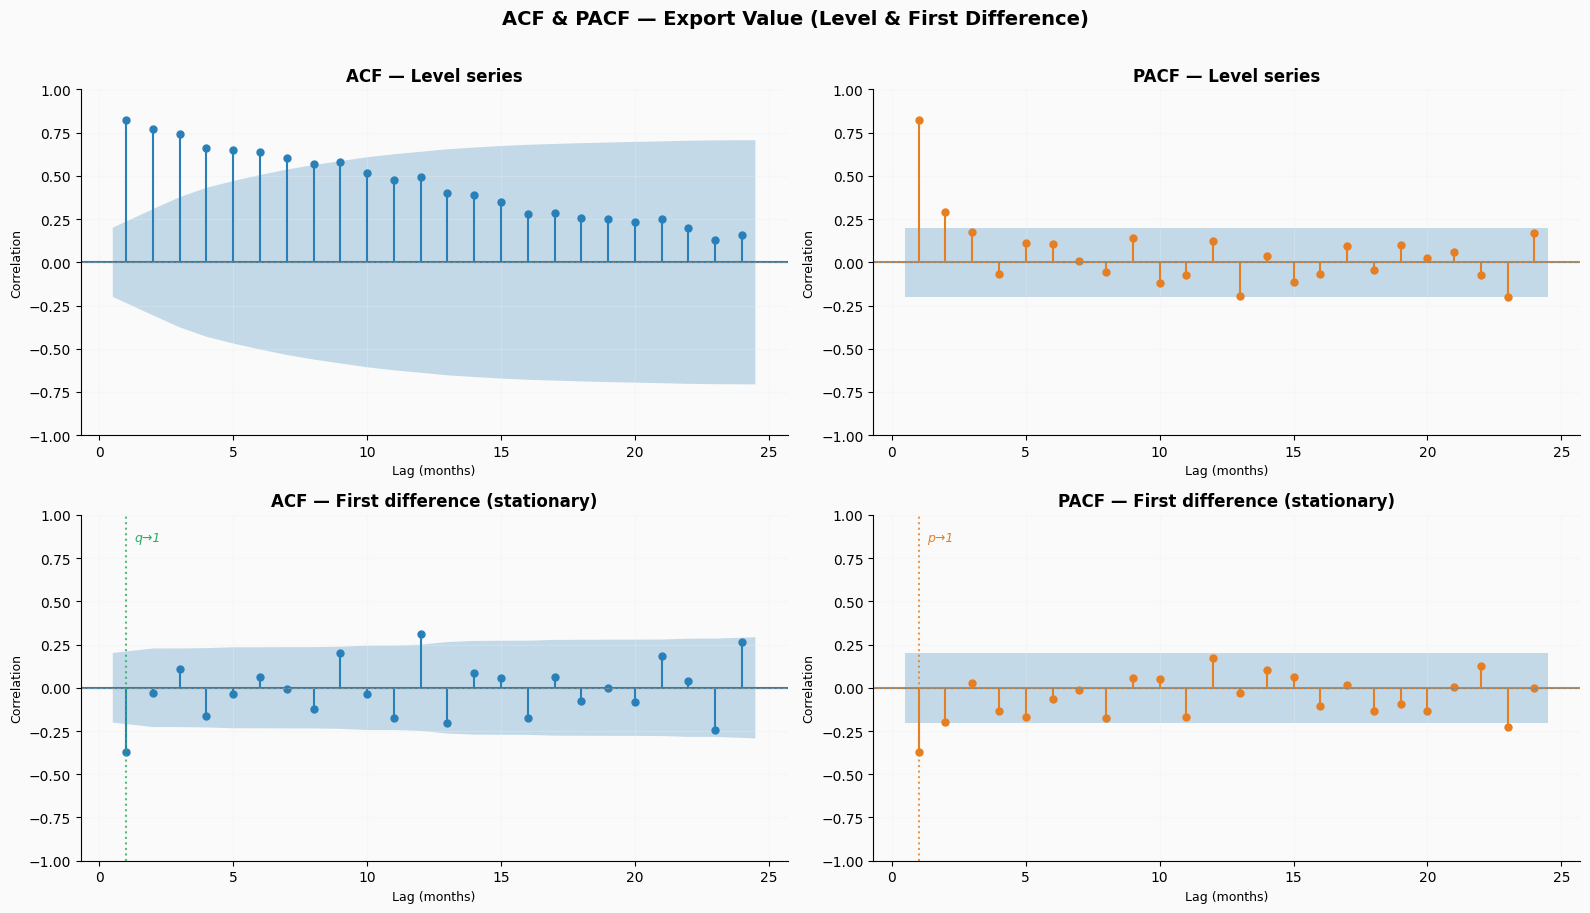

In [ ]:
def fmt_m(x, _):
    """Format y-axis as $XXk M"""
    return f'${x/1000:.0f}k'

COLORS = {
    'actual'  : '#2C3E50',
    'arima'   : '#2980B9',
    'lstm'    : '#27AE60',
    'hybrid'  : '#E67E22',
    'ci'      : '#AED6F1',
    'ci2'     : '#A9DFBF',
    'ci3'     : '#FAD7A0',
    'grid'    : '#ECF0F1',
    'covid'   : '#E74C3C',
}
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('ACF & PACF — Export Value (Level & First Difference)',
             fontsize=14, fontweight='bold', y=1.01)

acf_kws  = dict(lags=24, alpha=0.05, color=COLORS['arima'],
                vlines_kwargs={'colors': COLORS['arima'], 'linewidth': 1.5},
                zero=False)
pacf_kws = dict(lags=24, alpha=0.05, method='ywm',
                color=COLORS['hybrid'],
                vlines_kwargs={'colors': COLORS['hybrid'], 'linewidth': 1.5},
                zero=False)

# Row 0 — Level series
plot_acf( monthly['Export_Value'].dropna(), ax=axes[0, 0], **acf_kws)
plot_pacf(monthly['Export_Value'].dropna(), ax=axes[0, 1], **pacf_kws)
axes[0, 0].set_title('ACF — Level series', fontweight='bold')
axes[0, 1].set_title('PACF — Level series', fontweight='bold')

# Row 1 — First-differenced series
plot_acf( export_d1.dropna(), ax=axes[1, 0], **acf_kws)
plot_pacf(export_d1.dropna(), ax=axes[1, 1], **pacf_kws)
axes[1, 0].set_title('ACF — First difference (stationary)', fontweight='bold')
axes[1, 1].set_title('PACF — First difference (stationary)', fontweight='bold')

for ax in axes.flat:
    ax.set_facecolor('#FAFAFA')
    ax.axhline(0, color='#7F8C8D', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Lag (months)', fontsize=9)
    ax.set_ylabel('Correlation',  fontsize=9)
    ax.grid(True, alpha=0.3, color=COLORS['grid'])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Annotate suggested orders
axes[1, 0].axvline(x=1, color=COLORS['lstm'],   linestyle=':', alpha=0.8, linewidth=1.5)
axes[1, 1].axvline(x=1, color=COLORS['hybrid'], linestyle=':', alpha=0.8, linewidth=1.5)
axes[1, 0].text(1.3, axes[1,0].get_ylim()[1]*0.85, 'q→1', color=COLORS['lstm'],
                fontsize=9, fontstyle='italic')
axes[1, 1].text(1.3, axes[1,1].get_ylim()[1]*0.85, 'p→1', color=COLORS['hybrid'],
                fontsize=9, fontstyle='italic')

plt.tight_layout()
plt.savefig('visualizations/acf_pacf.png', dpi=300,
            bbox_inches='tight', facecolor='#FAFAFA')
plt.show()



VISUALIZATION 5.

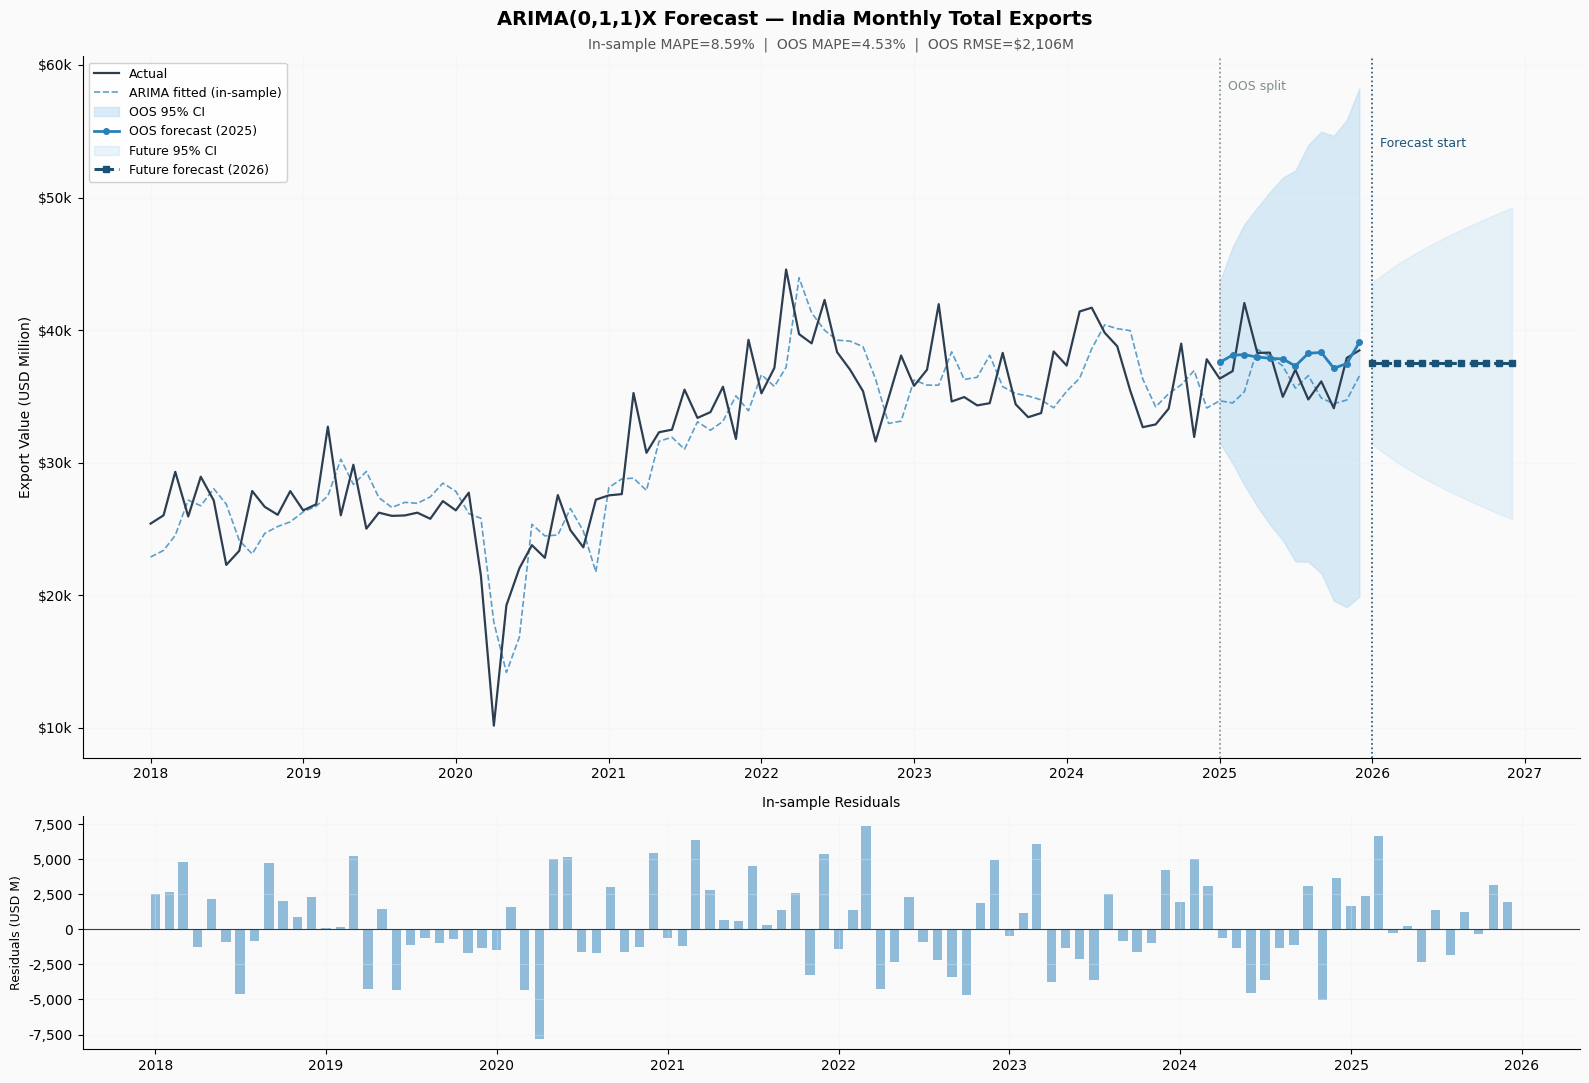

In [ ]:
def fmt_m(x, _):
    """Format y-axis as $XXk M"""
    return f'${x/1000:.0f}k'

COLORS = {
    'actual'  : '#2C3E50',
    'arima'   : '#2980B9',
    'lstm'    : '#27AE60',
    'hybrid'  : '#E67E22',
    'ci'      : '#AED6F1',
    'ci2'     : '#A9DFBF',
    'ci3'     : '#FAD7A0',
    'grid'    : '#ECF0F1',
    'covid'   : '#E74C3C',
}
def period_to_dt(idx):
    return idx.to_timestamp()

hist_dates    = period_to_dt(monthly.index)
fitted_dates  = period_to_dt(best_fit.fittedvalues.index)
oos_dates     = period_to_dt(oos_fc.predicted_mean.index)
oos_ci_vals   = oos_fc.conf_int(alpha=0.05)
future_dates  = period_to_dt(future_mean.index)
future_ci_lo  = future_ci.iloc[:, 0].values
future_ci_hi  = future_ci.iloc[:, 1].values

fig, axes = plt.subplots(2, 1, figsize=(16, 11),
                         gridspec_kw={'height_ratios': [3, 1]})
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle(f'ARIMA({best_p},{best_d},{best_q})X Forecast — India Monthly Total Exports',
             fontsize=14, fontweight='bold')

ax = axes[0]
ax.set_facecolor('#FAFAFA')

# In-sample history
ax.plot(hist_dates, monthly['Export_Value'].values,
        color=COLORS['actual'], linewidth=1.6, label='Actual', zorder=3)

# Fitted values (in-sample)
ax.plot(fitted_dates, best_fit.fittedvalues.values,
        color=COLORS['arima'], linewidth=1.2, linestyle='--',
        alpha=0.75, label='ARIMA fitted (in-sample)', zorder=2)

# OOS predictions + CI
ax.fill_between(oos_dates,
                oos_ci_vals.iloc[:, 0].values,
                oos_ci_vals.iloc[:, 1].values,
                color=COLORS['ci'], alpha=0.45, label='OOS 95% CI')
ax.plot(oos_dates, oos_fc.predicted_mean.values,
        color=COLORS['arima'], linewidth=2.0,
        marker='o', markersize=4, label='OOS forecast (2025)', zorder=4)

# Future forecast + CI
ax.fill_between(future_dates, future_ci_lo, future_ci_hi,
                color=COLORS['ci'], alpha=0.25, label='Future 95% CI')
ax.plot(future_dates, future_mean.values,
        color='#1A5276', linewidth=2.2,
        marker='s', markersize=4, linestyle='-.',
        label='Future forecast (2026)', zorder=5)


# Train/test divider
split_date = period_to_dt(endog_fit.index[-N_TEST: -N_TEST+1])
ax.axvline(x=split_date[0], color='#7F8C8D', linestyle=':', linewidth=1.2)
ax.text(split_date[0], ax.get_ylim()[1] * 0.97,
        '  OOS split', color='#7F8C8D', fontsize=9, va='top')

# Future divider
ax.axvline(x=future_dates[0], color='#1A5276', linestyle=':', linewidth=1.2)
ax.text(future_dates[0], ax.get_ylim()[1] * 0.90,
        '  Forecast start', color='#1A5276', fontsize=9, va='top')

ax.yaxis.set_major_formatter(FuncFormatter(fmt_m))
ax.set_ylabel('Export Value (USD Million)', fontsize=10)
ax.set_title(f'In-sample MAPE={mape_is:.2f}%  |  OOS MAPE={oos_mape:.2f}%  |  ' \
             f'OOS RMSE=${oos_rmse:,.0f}M',
             fontsize=10, color='#555')
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3, color=COLORS['grid'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Residual subplot
ax2 = axes[1]
ax2.set_facecolor('#FAFAFA')
resid_plot = best_fit.resid
resid_dates = period_to_dt(resid_plot.index)
ax2.bar(resid_dates, resid_plot.values, color=COLORS['arima'],
        alpha=0.5, width=20)
ax2.axhline(0, color='#2C3E50', linewidth=0.8)
ax2.set_ylabel('Residuals (USD M)', fontsize=9)
ax2.set_title('In-sample Residuals', fontsize=10)
ax2.grid(True, alpha=0.3, color=COLORS['grid'])
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('visualizations/arima_forecast.png', dpi=300,
            bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

In [ ]:
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# **2. LSTM**


In [ ]:
input_file = 'india_monthly_exports_with_indicators.xlsx'
df = pd.read_excel(input_file, sheet_name='Complete Data')
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'])

monthly = (df.groupby('Date')
             .agg(Export_Value   = ('Export_Value',   'sum'),
                  GDP_Growth      = ('gdp_growth',      'first'),
                  Inflation_Rate = ('Inflation_rate',  'first'),
                  REER           = ('REER',            'first'))
             .reset_index()
             .sort_values('Date'))
monthly.set_index('Date', inplace=True)
monthly.index = pd.DatetimeIndex(monthly.index).to_period('M')

tf.random.set_seed(42)
np.random.seed(42)
LOOKBACK = 12
N_TEST   = 12

# FEATURE ENGINEERING
monthly['Export_Lag1']  = monthly['Export_Value'].shift(1)
monthly['Export_Lag3']  = monthly['Export_Value'].shift(3)
monthly['Export_Lag12'] = monthly['Export_Value'].shift(12)

monthly['month_sin'] = np.sin(2*np.pi*monthly.index.month/12)
monthly['month_cos'] = np.cos(2*np.pi*monthly.index.month/12)

monthly = monthly.dropna()

features = [
'Export_Value',
'Export_Lag1',
'Export_Lag3',
'Export_Lag12',
'GDP_Growth',
'Inflation_Rate',
'REER',
'month_sin',
'month_cos'
]

data_raw = monthly[features].values.astype(np.float32)

# TRAIN TEST SPLIT
N = len(data_raw)
train_raw = data_raw[:N-N_TEST]
test_raw  = data_raw[N-N_TEST:]

# SCALING
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_raw)
test_scaled  = scaler.transform(test_raw)

# INVERSE TRANSFORM FUNCTION

def inverse_export(scaled_vals):
  dummy = np.zeros((len(scaled_vals), len(features)))
  dummy[:,0] = scaled_vals
  return scaler.inverse_transform(dummy)[:,0]


# SEQUENCE GENERATOR
def make_sequences_direct(data, lookback, horizon):

    X = []
    y = []

    for i in range(lookback, len(data)-horizon+1):

        X.append(data[i-lookback:i,:])
        y.append(data[i:i+horizon,0])

    return np.array(X), np.array(y)


X_train , y_train = make_sequences_direct(train_scaled,LOOKBACK,N_TEST)

print("Training sequences:",len(X_train))
print("X shape:",X_train.shape)
print("y shape:",y_train.shape)


# LSTM MODEL

def build_small_lstm():

    inp = Input(shape=(LOOKBACK,len(features)))
    x = LSTM(8,return_sequences=False)(inp)
    x = Dropout(0.2)(x)
    x = Dense(6,activation='relu')(x)
    out = Dense(N_TEST,activation='linear')(x)
    model = Model(inp,out)
    model.compile(
        optimizer = Adam(learning_rate=5e-4),
        loss = 'mse',
        metrics = ['mae']

    )
    return model
model = build_small_lstm()
model.summary()

# TRAIN MODEL

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs = 500,
    batch_size = 8,
    validation_split = 0.1,
    shuffle=False,
    callbacks=[early_stop],
    verbose=1
    )

# OUT OF SAMPLE PREDICTION
last_window = train_scaled[-LOOKBACK:].reshape(1,LOOKBACK,len(features))
pred_scaled = model.predict(last_window).flatten()
y_pred = inverse_export(pred_scaled)
y_true = inverse_export(test_scaled[:,0])

# METRICS

rmse = np.sqrt(mean_squared_error(y_true,y_pred))
mae  = mean_absolute_error(y_true,y_pred)
mape = np.mean(np.abs((y_true-y_pred)/y_true))*100
r2 = 1 - np.sum((y_true-y_pred)**2) / np.sum((y_true-y_true.mean())**2)

print("\nMODEL PERFORMANCE")
print("RMSE:",rmse)
print("MAE:",mae)
print("MAPE:",mape)
print("R2:",r2)

# MONTHLY RESULT TABLE

test_index = monthly.index[-N_TEST:]
print("\nMonth     Actual     Predicted")
for i,p in enumerate(test_index):

    print(p,y_true[i],y_pred[i])


# FUTURE FORECAST (12 MONTH)

full_scaled = scaler.transform(data_raw)
future_window = full_scaled[-LOOKBACK:].reshape(1,LOOKBACK,len(features))
future_scaled = model.predict(future_window).flatten()
future_preds = inverse_export(future_scaled)
future_index = pd.period_range(
    start = monthly.index[-1]+1,
    periods = 12,
    freq='M'
    )

print("\n12 Month Future Forecast")
for p,val in zip(future_index,future_preds):
  print(p,val)

Training sequences: 49
X shape: (49, 12, 9)
y shape: (49, 12)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 12, 9)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 8)              │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │            84 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 714 (2.79 KB)

 Trainable params: 714 (2.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - loss: 0.5418 - mae: 0.7054 - val_loss: 0.6341 - val_mae: 0.7893
Epoch 2/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.5231 - mae: 0.6919 - val_loss: 0.6142 - val_mae: 0.7769
Epoch 3/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.4965 - mae: 0.6728 - val_loss: 0.5947 - val_mae: 0.7644
Epoch 4/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.4851 - mae: 0.6644 - val_loss: 0.5761 - val_mae: 0.7519
Epoch 5/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.4669 - mae: 0.6502 - val_loss: 0.5584 - val_mae: 0.7396
Epoch 6/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.4590 - mae: 0.6409 - val_loss: 0.5417 - val_mae: 0.7275
Epoch 7/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.4406 - mae: 0.6296 - val_loss: 0.5253 - val_mae: 0.7151
Epoch 8/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.4359 - mae: 0.6248 - val_loss: 0.5105 - val_mae: 0.7036
Epoch 9/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.4222 - mae: 

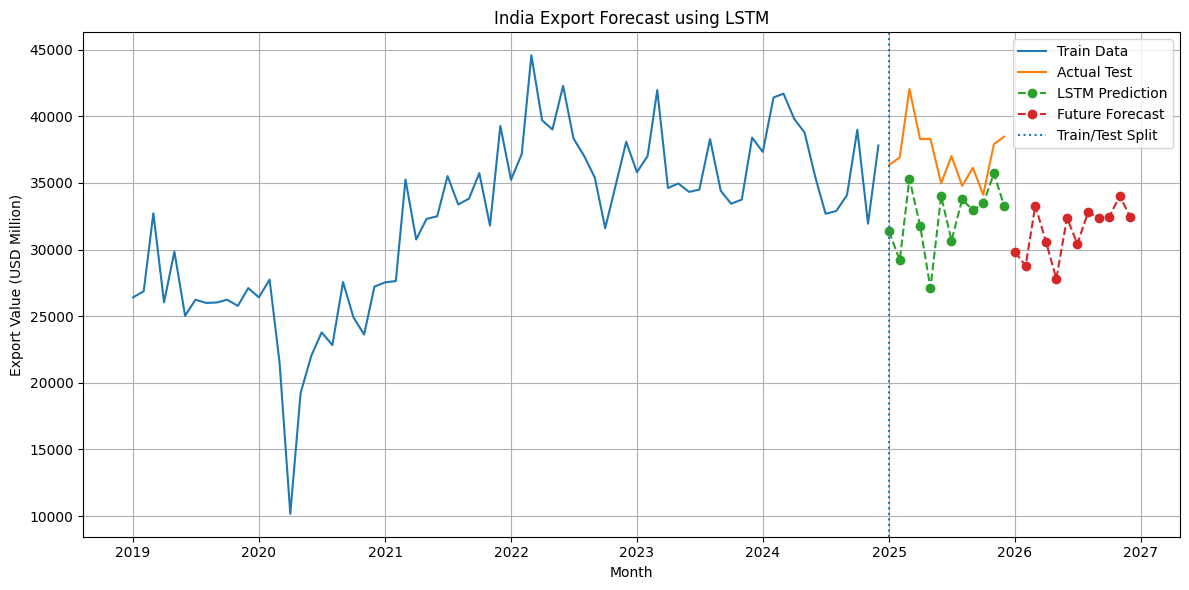

In [ ]:
# Historical export series
history_export = monthly['Export_Value']

train_period_index = monthly.index[:len(history_export)-N_TEST]
test_period_index  = monthly.index[len(history_export)-N_TEST:]

# Convert predictions to Series
pred_series = pd.Series(y_pred, index=test_period_index)
future_series = pd.Series(future_preds, index=future_index)

# Plot
plt.figure(figsize=(12,6))

# Convert PeriodIndex to TimestampIndex for plotting
plt.plot(train_period_index.to_timestamp(),
         history_export.loc[train_period_index],
         label="Train Data")

plt.plot(test_period_index.to_timestamp(),
         history_export.loc[test_period_index],
         label="Actual Test")

plt.plot(pred_series.index.to_timestamp(), # Convert index of pred_series
         pred_series,
         linestyle='--',
         marker='o',
         label="LSTM Prediction")

plt.plot(future_series.index.to_timestamp(), # Convert index of future_series
         future_series,
         linestyle='--',
         marker='o',
         label="Future Forecast")

plt.axvline(test_period_index.to_timestamp()[0], linestyle=":", label="Train/Test Split")
plt.title("India Export Forecast using LSTM")
plt.xlabel("Month")
plt.ylabel("Export Value (USD Million)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# **3. HYBRID**

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

# Define ARIMA best parameters explicitly to ensure availability
best_p = 0
best_d = 1
best_q = 1

input_file = 'india_monthly_exports_with_indicators.xlsx'
df = pd.read_excel(input_file, sheet_name='Complete Data')
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'])

monthly = (df.groupby('Date')
             .agg(Export_Value   = ('Export_Value',   'sum'),
                  GDP_Growth     = ('gdp_growth',     'first'),
                  Inflation_Rate = ('Inflation_rate', 'first'),
                  REER           = ('REER',           'first'))
             .reset_index()
             .sort_values('Date'))
monthly.set_index('Date', inplace=True)
monthly.index = pd.DatetimeIndex(monthly.index).to_period('M')


N_TEST   = 12
LOOKBACK = 6

endog_all = monthly['Export_Value'].dropna()
exog_all  = monthly[['GDP_Growth', 'Inflation_Rate', 'REER']].loc[endog_all.index]
exog_all  = exog_all.ffill().dropna()
valid_idx = endog_all.index.intersection(exog_all.index)
endog_all = endog_all.loc[valid_idx]
exog_all  = exog_all.loc[valid_idx]

train_endog = endog_all.iloc[:-N_TEST]
test_endog  = endog_all.iloc[-N_TEST:]
train_exog  = exog_all.iloc[:-N_TEST]
test_exog   = exog_all.iloc[-N_TEST:]

print(f"Train: {len(train_endog)} months | Test: {len(test_endog)} months")

#Fit ARIMA on training data only

print(f"\nFitting ARIMA({best_p},{best_d},{best_q}) on training data...")

arima_train_fit = ARIMA(
    endog = train_endog,
    exog  = train_exog,
    order = (best_p, best_d, best_q)
).fit(method_kwargs={"warn_convergence": False})

# OOS forecast using ACTUAL 2025 exog values (not rollout)
arima_oos_fc   = arima_train_fit.get_forecast(steps=N_TEST, exog=test_exog)
arima_oos_pred = arima_oos_fc.predicted_mean

# Training residuals for LSTM to learn from
arima_resid_train = train_endog - arima_train_fit.fittedvalues

print(f"Residuals — mean: {arima_resid_train.mean():.2f}, "
      f"std: {arima_resid_train.std():.2f}")

# Scale features and residuals

features_h    = ['Export_Value', 'GDP_Growth', 'Inflation_Rate', 'REER']
feat_train_raw = monthly[features_h].loc[train_endog.index].values.astype(np.float32)
feat_test_raw  = monthly[features_h].loc[test_endog.index].values.astype(np.float32)
resid_train    = arima_resid_train.values.astype(np.float32)
n_feat_h       = len(features_h)

feat_scaler    = MinMaxScaler(feature_range=(0, 1))
feat_train_sc  = feat_scaler.fit_transform(feat_train_raw)
feat_test_sc   = feat_scaler.transform(feat_test_raw)

resid_scaler   = MinMaxScaler(feature_range=(-1, 1))
resid_train_sc = resid_scaler.fit_transform(
    resid_train.reshape(-1, 1)).flatten()

# Build sequences

def make_residual_sequences(feat_sc, target_sc, lookback):
    X, y = [], []
    for i in range(lookback, len(target_sc)):
        X.append(feat_sc[i - lookback : i, :])
        y.append(target_sc[i])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train_h, y_train_h = make_residual_sequences(
    feat_train_sc, resid_train_sc, LOOKBACK)


# For OOS test: use ACTUAL 2025 feature values directly.
# Do NOT use autoregressive rollout here.
# Stitch last LOOKBACK training rows + actual test rows.

feat_test_full = np.concatenate(
    [feat_train_sc[-LOOKBACK:], feat_test_sc], axis=0)

X_test_h = np.array([
    feat_test_full[i - LOOKBACK : i, :]
    for i in range(LOOKBACK, len(feat_test_full))
], dtype=np.float32)

print(f"\nTraining sequences : {len(X_train_h)}")
print(f"Test sequences     : {len(X_test_h)}")

# Build model

def build_residual_lstm(lr=5e-4):
    model = Sequential([
        Input(shape=(LOOKBACK, n_feat_h)),
        LSTM(8, return_sequences=False,
             activation='tanh',
             recurrent_activation='sigmoid'),
        Dropout(0.2),
        Dense(6, activation='relu'),
        Dense(1, activation='linear'),
    ])
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='mse',
        metrics=['mae']
    )
    return model

lstm_resid = build_residual_lstm()
lstm_resid.summary()
print(f"\nParameters: {lstm_resid.count_params()} | "
      f"Sequences: {len(X_train_h)} | "
      f"Ratio: {lstm_resid.count_params()/len(X_train_h):.1f}")

#Train with EarlyStopping

tf.random.set_seed(42)
lstm_resid = build_residual_lstm(lr=5e-4)

early_stop_h = EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True
)

print("\nTraining residual LSTM...")
hist_h = lstm_resid.fit(
    X_train_h, y_train_h,
    epochs=500,
    batch_size=8,
    validation_split=0.1,
    shuffle=False,
    callbacks=[early_stop_h],
    verbose=0
)

best_epoch_h    = np.argmin(hist_h.history['val_loss']) + 1
best_val_loss_h = min(hist_h.history['val_loss'])
stopped_at_h    = len(hist_h.history['loss'])

print(f"Stopped at epoch : {stopped_at_h}/500")
print(f"Best epoch       : {best_epoch_h}")
print(f"Best val_loss    : {best_val_loss_h:.6f}")

# OOS prediction using ACTUAL test features
# (no rollout — actual 2025 data is known)

resid_pred_sc = lstm_resid.predict(X_test_h, verbose=0).flatten()
resid_pred    = resid_scaler.inverse_transform(
    resid_pred_sc.reshape(-1, 1)).flatten()

hybrid_pred = arima_oos_pred.values + resid_pred
y_true_h    = test_endog.values

#Metrics

def compute_metrics(true, pred, name):
    rmse = np.sqrt(mean_squared_error(true, pred))
    mae  = mean_absolute_error(true, pred)
    mape = np.mean(np.abs((true - pred) /
                   np.where(true == 0, np.nan, true))) * 100
    r2   = 1 - (np.sum((true - pred) ** 2) /
                np.sum((true - true.mean()) ** 2))
    bias = np.mean(true - pred)
    return {'Model': name, 'RMSE': round(rmse, 2),
            'MAE': round(mae, 2), 'MAPE': round(mape, 2),
            'R2': round(r2, 4), 'Bias': round(bias, 2)}

m_arima  = compute_metrics(y_true_h, arima_oos_pred.values,
                           f'ARIMA({best_p},{best_d},{best_q})')
m_hybrid = compute_metrics(y_true_h, hybrid_pred, 'Hybrid ARIMA+LSTM')

print(f"\n{'Model':<22} {'RMSE':>10} {'MAE':>10} "
      f"{'MAPE%':>8} {'R²':>10} {'Bias':>10}")
print(f"{'─' * 66}")
for ms in [m_arima, m_hybrid]:
    print(f" {ms['Model']:<22} {ms['RMSE']:>10.2f} {ms['MAE']:>10.2f} "
          f"{ms['MAPE']:>8.2f} {ms['R2']:>10.4f} {ms['Bias']:>10.2f}")

# Month detail
print(f"\n{'Month':<12} {'Actual':>10} {'ARIMA':>10} "
      f"{'LSTM_corr':>12} {'Hybrid':>10} {'Err%':>7}")
print(f"{'─' * 68}")
for i, per in enumerate(test_endog.index):
    err = (y_true_h[i] - hybrid_pred[i]) / y_true_h[i] * 100
    print(f" {str(per):<12} {y_true_h[i]:>10.2f} "
          f"{arima_oos_pred.values[i]:>10.2f} "
          f"{resid_pred[i]:>+12.2f} "
          f"{hybrid_pred[i]:>10.2f} "
          f"{err:>6.2f}%")

# Diagnostics

hybrid_errors = y_true_h - hybrid_pred
bias_h        = hybrid_errors.mean()
jb_h          = stats.jarque_bera(hybrid_errors)

print(f"\nHybrid residuals:")
print(f"  Bias : {bias_h:+.2f} USD M  "
      f"{'✓ Unbiased' if abs(bias_h) < 500 else '⚠ Bias present'}")
print(f"  Std  : {hybrid_errors.std():.2f} USD M")
print(f"  JB   : stat={jb_h.statistic:.4f}  p={jb_h.pvalue:.4f}  "
      f"({'Normal' if jb_h.pvalue > 0.05 else 'Non-normal'}) ")

improvement = m_arima['MAPE'] - m_hybrid['MAPE']
print(f"\nHybrid vs ARIMA: "
      f"{'improvement' if improvement > 0 else 'worsening'} "
      f"of {abs(improvement):.2f}pp in MAPE")

# 2026 Future Forecast
# Rollout IS used here — 2026 data is genuinely unknown.
# But corrections are capped to prevent explosion.

arima_full_fit = ARIMA(
    endog = endog_all,
    exog  = exog_all,
    order = (best_p, best_d, best_q)
).fit(method_kwargs={"warn_convergence": False})

fut_exog = pd.DataFrame({
    'GDP_Growth'    : [monthly['GDP_Growth'].iloc[-1]]    * 12,
    'Inflation_Rate': [monthly['Inflation_Rate'].iloc[-1]] * 12,
    'REER'          : [monthly['REER'].iloc[-1]]           * 12
})

arima_future_fc = arima_full_fit.get_forecast(steps=12, exog=fut_exog)
arima_future    = arima_future_fc.predicted_mean.values
arima_future_ci = arima_future_fc.conf_int(alpha=0.05)

# FUTURE ROLLOUT

max_correction = 2 * arima_resid_train.std()

full_feat_raw = monthly[features_h].loc[endog_all.index].values.astype(np.float32)
full_feat_sc  = feat_scaler.transform(full_feat_raw)
current_seq   = full_feat_sc[-LOOKBACK:].copy()

future_resid_sc = []
for step in range(12):
    inp  = current_seq.reshape(1, LOOKBACK, n_feat_h)
    p_sc = lstm_resid.predict(inp, verbose=0)[0, 0]
    future_resid_sc.append(p_sc)

    next_exp_sc = feat_scaler.transform(
        np.array([[arima_future[step],
                   full_feat_sc[-1, 1],
                   full_feat_sc[-1, 2],
                   full_feat_sc[-1, 3]]]))[0, 0]
    new_row = np.array([[next_exp_sc,
                         full_feat_sc[-1, 1],
                         full_feat_sc[-1, 2],
                         full_feat_sc[-1, 3]]], dtype=np.float32)
    current_seq = np.concatenate([current_seq[1:], new_row], axis=0)

future_resid_raw = resid_scaler.inverse_transform(
    np.array(future_resid_sc).reshape(-1, 1)).flatten()

# Apply cap
future_resid_capped = np.clip(
    future_resid_raw, -max_correction, max_correction)

hybrid_future = arima_future + future_resid_capped
ci_lo = arima_future_ci.iloc[:, 0].values + future_resid_capped
ci_hi = arima_future_ci.iloc[:, 1].values + future_resid_capped

future_idx_h = pd.period_range(
    start=endog_all.index[-1] + 1, periods=12, freq='M')

print(f"\n2026 Forecast (cap = ±${max_correction:,.0f}M):")
print(f"\n{'Month':<12} {'ARIMA':>12} {'LSTM_corr':>12} "
      f"{'Hybrid':>12} {'CI_Low':>10} {'CI_High':>10}")
print(f"{'─' * 72}")
for i, per in enumerate(future_idx_h):
    print(f" {str(per):<12} {arima_future[i]:>12.2f} "
          f"{future_resid_capped[i]:>+12.2f} "
          f"{hybrid_future[i]:>12.2f} "
          f"{ci_lo[i]:>10.2f} "
          f"{ci_hi[i]:>10.2f}")

Train: 84 months | Test: 12 months

Fitting ARIMA(0,1,1) on training data...
Residuals — mean: 1069.69, std: 8252.94

Training sequences : 78
Test sequences     : 12


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 8)              │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 477 (1.86 KB)

 Trainable params: 477 (1.86 KB)

 Non-trainable params: 0 (0.00 B)


Parameters: 477 | Sequences: 78 | Ratio: 6.1

Training residual LSTM...
Stopped at epoch : 47/500
Best epoch       : 22
Best val_loss    : 0.008533

Model                        RMSE        MAE    MAPE%         R²       Bias
──────────────────────────────────────────────────────────────────
 ARIMA(0,1,1)              2106.41    1660.65     4.53    -0.0577    -816.05
 Hybrid ARIMA+LSTM         5960.38    5094.11    13.95    -7.4686   -4558.22

Month            Actual      ARIMA    LSTM_corr     Hybrid    Err%
────────────────────────────────────────────────────────────────────
 2025-01        36338.46   37564.23      +461.55   38025.78  -4.64%
 2025-02        36910.95   38119.75      +434.29   38554.04  -4.45%
 2025-03        42047.58   38146.84      +685.41   38832.24   7.65%
 2025-04        38283.21   37972.09     +1557.69   39529.78  -3.26%
 2025-05        38303.31   37877.73     +2187.46   40065.20  -4.60%
 2025-06        34969.76   37823.32     +2739.85   40563.17 -15.99%
 2025-07

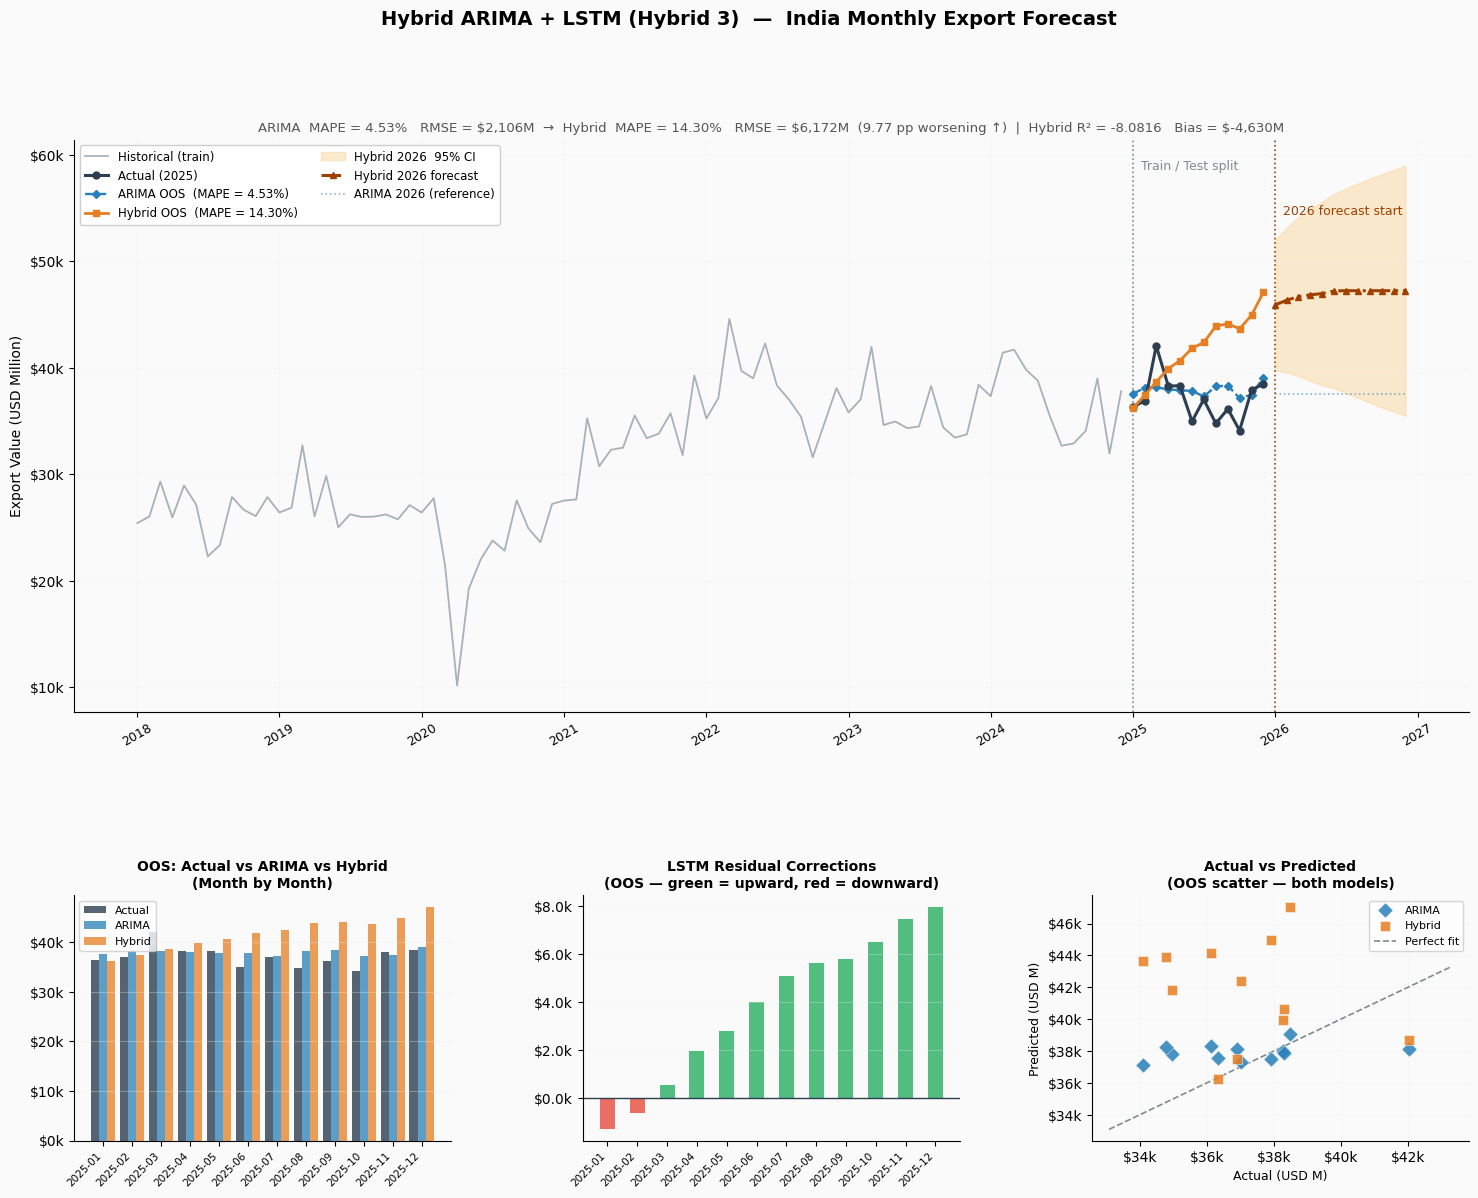

Saved: visualizations/hybrid3_forecast.png

2026 Hybrid 3 Forecast  (correction cap = ±$16,506M):

Month               ARIMA    LSTM corr       Hybrid     CI Low    CI High
────────────────────────────────────────────────────────────────────────
  2026-01          37493.16     +8410.94     45904.10   39784.60   52023.60
  2026-02          37493.16     +8861.35     46354.51   39529.17   53179.86
  2026-03          37493.16     +9175.55     46668.72   39203.97   54133.46
  2026-04          37493.16     +9347.16     46840.32   38786.78   54893.86
  2026-05          37493.16     +9462.18     46955.34   38353.21   55557.46
  2026-06          37493.16     +9707.09     47200.26   38082.49   56318.02
  2026-07          37493.16     +9731.87     47225.03   37619.27   56830.80
  2026-08          37493.16     +9731.87     47225.03   37154.89   57295.18
  2026-09          37493.16     +9731.87     47225.03   36711.00   57739.06
  2026-10          37493.16     +9731.87     47225.03   36285.11   581

In [ ]:
COLORS = {
    'actual' : '#2C3E50',
    'train'  : '#85929E',
    'arima'  : '#2980B9',
    'hybrid' : '#E67E22',
    'future' : '#A04000',
    'ci'     : '#FAD7A0',
    'resid_pos': '#27AE60',
    'resid_neg': '#E74C3C',
    'grid'   : '#ECF0F1',
}

def fmt_k(x, _):
    return f'${x/1000:.0f}k'

def period_to_dt(idx):
    return idx.to_timestamp()


oos_index    = test_endog.index                  # PeriodIndex, 12 months
oos_dates    = period_to_dt(oos_index)
future_dates = period_to_dt(future_idx_h)
all_dates    = period_to_dt(endog_all.index)
month_labels = [str(p) for p in oos_index]

improvement  = m_arima['MAPE'] - m_hybrid['MAPE']
direction    = 'improvement ↓' if improvement > 0 else 'worsening ↑'

# Figure layout
#   gs[0, :]  — Main forecast (full width, tall)
#   gs[1, 0]  — OOS bar chart  (actual / arima / hybrid per month)
#   gs[1, 1]  — LSTM residual corrections bar chart
#   gs[1, 2]  — Actual vs Predicted scatter (both models)

fig = plt.figure(figsize=(18, 13))
fig.patch.set_facecolor('#FAFAFA')
gs  = gridspec.GridSpec(2, 3, figure=fig,
                        height_ratios=[2.8, 1.2],
                        hspace=0.45, wspace=0.35)

ax_main  = fig.add_subplot(gs[0, :])
ax_bar   = fig.add_subplot(gs[1, 0])
ax_resid = fig.add_subplot(gs[1, 1])
ax_scat  = fig.add_subplot(gs[1, 2])

fig.suptitle(
    'Hybrid ARIMA + LSTM (Hybrid 3)  —  India Monthly Export Forecast',
    fontsize=14, fontweight='bold'
)

#  Main forecast
ax_main.set_facecolor('#FAFAFA')

# Full historical series (training portion = grey, test portion = dark)
train_index = endog_all.index[:-N_TEST]
ax_main.plot(period_to_dt(train_index),
             endog_all.iloc[:-N_TEST].values,
             color=COLORS['train'], linewidth=1.3, alpha=0.7,
             label='Historical (train)', zorder=2)

# OOS actual (dark, thick)
ax_main.plot(oos_dates, y_true_h,
             color=COLORS['actual'], linewidth=2.2,
             marker='o', markersize=5,
             label='Actual (2025)', zorder=5)

# OOS ARIMA
ax_main.plot(oos_dates, arima_oos_pred.values,
             color=COLORS['arima'], linewidth=1.7,
             linestyle='--', marker='D', markersize=4,
             label=f"ARIMA OOS  (MAPE = {m_arima['MAPE']:.2f}%)", zorder=4)

# OOS Hybrid
ax_main.plot(oos_dates, hybrid_pred,
             color=COLORS['hybrid'], linewidth=2.0,
             marker='s', markersize=5,
             label=f"Hybrid OOS  (MAPE = {m_hybrid['MAPE']:.2f}%)", zorder=6)

# 2026 CI band
ax_main.fill_between(future_dates, ci_lo, ci_hi,
                     color=COLORS['ci'], alpha=0.5,
                     label='Hybrid 2026  95% CI')

# 2026 Hybrid forecast
ax_main.plot(future_dates, hybrid_future,
             color=COLORS['future'], linewidth=2.2,
             marker='^', markersize=5, linestyle='-.',
             label='Hybrid 2026 forecast', zorder=7)

# 2026 ARIMA (faint reference)
ax_main.plot(future_dates, arima_future,
             color=COLORS['arima'], linewidth=1.2,
             linestyle=':', alpha=0.55,
             label='ARIMA 2026 (reference)', zorder=3)

# Dividers
ax_main.axvline(oos_dates[0],    color='#7F8C8D',       linestyle=':', linewidth=1.2)
ax_main.axvline(future_dates[0], color=COLORS['future'], linestyle=':', linewidth=1.2)

ymax = ax_main.get_ylim()[1]
ax_main.text(oos_dates[0],    ymax * 0.97, '  Train / Test split',
             color='#7F8C8D',       fontsize=9, va='top')
ax_main.text(future_dates[0], ymax * 0.90, '  2026 forecast start',
             color=COLORS['future'], fontsize=9, va='top')

ax_main.yaxis.set_major_formatter(FuncFormatter(fmt_k))
ax_main.set_ylabel('Export Value (USD Million)', fontsize=10)
ax_main.set_title(
    f"ARIMA  MAPE = {m_arima['MAPE']:.2f}%   RMSE = ${m_arima['RMSE']:,.0f}M  →  "
    f"Hybrid  MAPE = {m_hybrid['MAPE']:.2f}%   RMSE = ${m_hybrid['RMSE']:,.0f}M  "
    f"({abs(improvement):.2f} pp {direction})  |  "
    f"Hybrid R² = {m_hybrid['R2']:.4f}   Bias = ${m_hybrid['Bias']:+,.0f}M",
    fontsize=9.5, color='#555'
)
ax_main.legend(loc='upper left', fontsize=8.5, framealpha=0.92, ncol=2)
ax_main.grid(True, alpha=0.3, color=COLORS['grid'])
ax_main.spines['top'].set_visible(False)
ax_main.spines['right'].set_visible(False)
ax_main.tick_params(axis='x', rotation=30, labelsize=9)

# OOS bar chart
ax_bar.set_facecolor('#FAFAFA')
x_pos = np.arange(N_TEST)
w     = 0.28

ax_bar.bar(x_pos - w,   y_true_h,           w, color=COLORS['actual'], alpha=0.80, label='Actual')
ax_bar.bar(x_pos,       arima_oos_pred.values, w, color=COLORS['arima'],  alpha=0.75, label='ARIMA')
ax_bar.bar(x_pos + w,   hybrid_pred,         w, color=COLORS['hybrid'], alpha=0.75, label='Hybrid')

ax_bar.set_xticks(x_pos)
ax_bar.set_xticklabels(month_labels, rotation=45, ha='right', fontsize=7.5)
ax_bar.yaxis.set_major_formatter(FuncFormatter(fmt_k))
ax_bar.set_title('OOS: Actual vs ARIMA vs Hybrid\n(Month by Month)',
                 fontweight='bold', fontsize=10)
ax_bar.legend(fontsize=8)
ax_bar.grid(True, alpha=0.3, axis='y', color=COLORS['grid'])
ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)

# LSTM residual corrections
ax_resid.set_facecolor('#FAFAFA')
colors_bar = [COLORS['resid_pos'] if v >= 0 else COLORS['resid_neg']
              for v in resid_pred]
ax_resid.bar(x_pos, resid_pred, color=colors_bar, alpha=0.80, width=0.5)
ax_resid.axhline(0, color='#2C3E50', linewidth=1.0)

ax_resid.set_xticks(x_pos)
ax_resid.set_xticklabels(month_labels, rotation=45, ha='right', fontsize=7.5)
ax_resid.yaxis.set_major_formatter(
    FuncFormatter(lambda v, _: f'${v/1000:.1f}k'))
ax_resid.set_title('LSTM Residual Corrections\n(OOS — green = upward, red = downward)',
                   fontweight='bold', fontsize=10)
ax_resid.grid(True, alpha=0.3, axis='y', color=COLORS['grid'])
ax_resid.spines['top'].set_visible(False)
ax_resid.spines['right'].set_visible(False)

# ─ Scatter actual vs predicted (both models)
ax_scat.set_facecolor('#FAFAFA')
all_actual = np.concatenate([y_true_h, y_true_h])
all_pred   = np.concatenate([arima_oos_pred.values, hybrid_pred])

ax_scat.scatter(y_true_h, arima_oos_pred.values,
                color=COLORS['arima'],  alpha=0.85, s=60,
                marker='D', edgecolors='white', linewidth=0.4,
                label='ARIMA', zorder=4)
ax_scat.scatter(y_true_h, hybrid_pred,
                color=COLORS['hybrid'], alpha=0.85, s=60,
                marker='s', edgecolors='white', linewidth=0.4,
                label='Hybrid', zorder=5)

mn = all_actual.min() * 0.97
mx = all_actual.max() * 1.03
ax_scat.plot([mn, mx], [mn, mx], '--', color='#7F8C8D',
             linewidth=1.2, label='Perfect fit', zorder=2)

ax_scat.set_xlabel('Actual (USD M)',    fontsize=9)
ax_scat.set_ylabel('Predicted (USD M)', fontsize=9)
ax_scat.set_title('Actual vs Predicted\n(OOS scatter — both models)',
                  fontweight='bold', fontsize=10)
ax_scat.xaxis.set_major_formatter(FuncFormatter(fmt_k))
ax_scat.yaxis.set_major_formatter(FuncFormatter(fmt_k))
ax_scat.legend(fontsize=8)
ax_scat.grid(True, alpha=0.3, color=COLORS['grid'])
ax_scat.spines['top'].set_visible(False)
ax_scat.spines['right'].set_visible(False)

plt.savefig('visualizations/hybrid3_forecast.png',
            dpi=300, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print("Saved: visualizations/hybrid3_forecast.png")

#  2026 forecast table
print(f"\n2026 Hybrid 3 Forecast  (correction cap = ±${max_correction:,.0f}M):")
print(f"\n{'Month':<12} {'ARIMA':>12} {'LSTM corr':>12} "
      f"{'Hybrid':>12} {'CI Low':>10} {'CI High':>10}")
print('─' * 72)
for i, per in enumerate(future_idx_h):
    print(f"  {str(per):<12} {arima_future[i]:>12.2f} "
          f"{future_resid_capped[i]:>+12.2f} "
          f"{hybrid_future[i]:>12.2f} "
          f"{ci_lo[i]:>10.2f} {ci_hi[i]:>10.2f}")